# Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#import geopandas as gpd
#from shapely.geometry import Polygon
#from shapely.geometry import Point
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm
from sklearn import preprocessing
from sklearn.cluster import Birch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.special import rel_entr, kl_div
from scipy.stats import entropy
import math
import time
import random
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

path_seoul_data = '/content/drive/MyDrive/Colab Notebooks/datasets/Seoul/'
path_lta_data = '/content/drive/MyDrive/Colab Notebooks/data_fusion_fcl/lta_data/'

path_data = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/data_tour/'
path_figure = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/figure_tour/'
path_result = '/content/drive/MyDrive/Colab Notebooks/Workspace/tour_generation/result_tour/'

def reduce_mem_usage(props):
    start_mem_usg = props.memory_usage().sum() / 1024**2
    #print("Memory usage of properties dataframe is :",start_mem_usg," MB")
    NAlist = [] # Keeps track of columns that have missing values filled in.
    for col in props.columns:
        if (props[col].dtype != object) & (props[col].dtype != 'category'):  # Exclude strings

            # make variables for Int, max and min
            IsInt = False
            mx = props[col].max()
            mn = props[col].min()

            # Integer does not support NA, therefore, NA needs to be filled
            if not np.isfinite(props[col]).all():
                NAlist.append(col)
                props[col].fillna(mn-1,inplace=True)

            # test if column can be converted to an integer
            asint = props[col].fillna(0).astype(np.int64)
            result = (props[col] - asint)
            result = result.sum()
            if result > -0.01 and result < 0.01:
                IsInt = True

            if IsInt:
                if mn >= 0:
                    if mx < 255:
                        props[col] = props[col].astype(np.uint8)
                    elif mx < 65535:
                        props[col] = props[col].astype(np.uint16)
                    elif mx < 4294967295:
                        props[col] = props[col].astype(np.uint32)
                    else:
                        props[col] = props[col].astype(np.uint64)
                else:
                    if mn > np.iinfo(np.int8).min and mx < np.iinfo(np.int8).max:
                        props[col] = props[col].astype(np.int8)
                    elif mn > np.iinfo(np.int16).min and mx < np.iinfo(np.int16).max:
                        props[col] = props[col].astype(np.int16)
                    elif mn > np.iinfo(np.int32).min and mx < np.iinfo(np.int32).max:
                        props[col] = props[col].astype(np.int32)
                    elif mn > np.iinfo(np.int64).min and mx < np.iinfo(np.int64).max:
                        props[col] = props[col].astype(np.int64)
            else:
                props[col] = props[col].astype(np.float32)

    mem_usg = props.memory_usage().sum() / 1024**2
    return props

Mounted at /content/drive


# Statistic

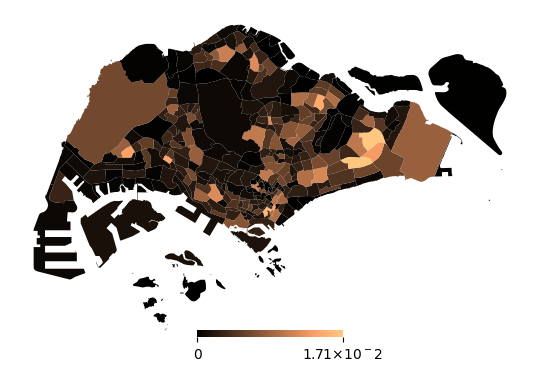

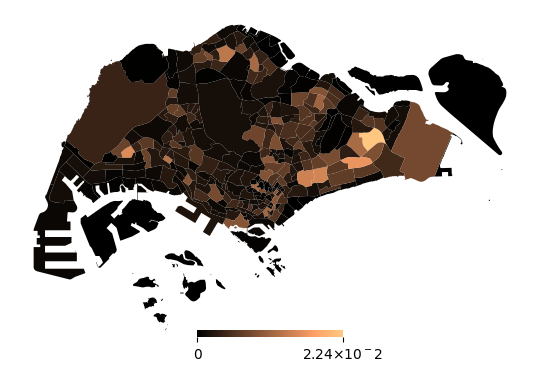

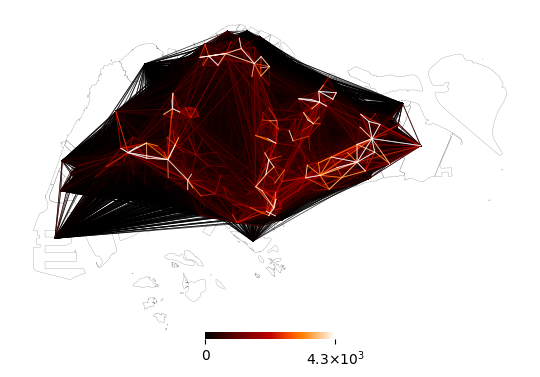

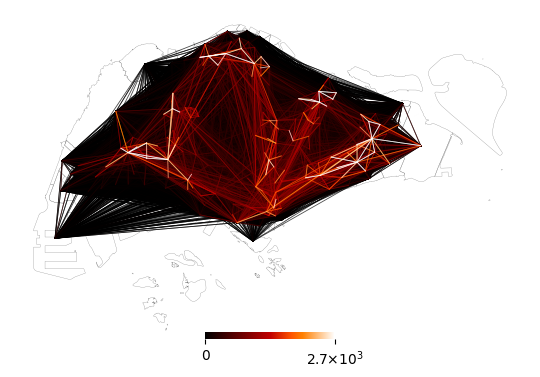

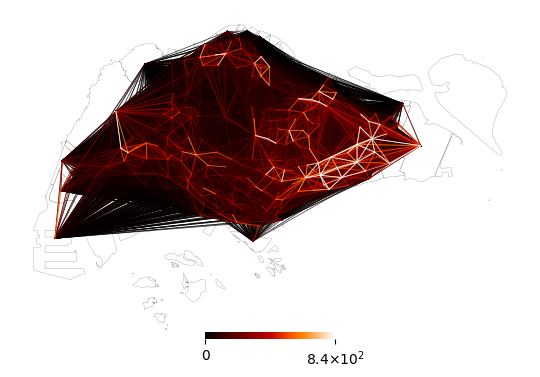

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np


def sci_notation(val, prec=2):
    """Format number: plain if <100, else a×10^n."""
    s = f"{val:.{prec}e}"  # e.g., 1.23e+05
    base, exp = s.split("e")
    exp = int(exp)
    return rf"{base}×10$^{exp}$"


def plot_space_subzone(
    df_,                      # DataFrame with columns [att_, COUNT]
    att_,                     # 'ORIGIN_SUBZONE' or 'DESTINATION_SUBZONE'
    cc,                       # caption label (e.g., time window or case label)
    maxx=None,                # optional vmax; if None, computed from data
    region='sgp',             # 'sgp' or 'seoul'
    color_map='copper',    # same default as your intra plot
    fig_x=5.5,
    fig_y=5.5,
    annotate=False            # set True if you want a small caption on the map
):
    """
    Plot per-subzone COUNT with continuous colormap.
    - Reads full subzone geometry, maps COUNT by subzone, fills missing with 0.
    - Colorbar inside the plot, horizontal, showing only ticks at 0 and max.
    - Scientific-style label for max (mantissa × 10^exp).
    """

    # 1) load all subzones
    gdf = gpd.read_file(path_data + f'data_{region}_subzone.shp')[['SUBZONE_C', 'geometry']]

    # 2) sum to subzone if needed, then map onto full GeoDataFrame
    zone_sum = df_.groupby(att_)['COUNT'].sum() if att_ in df_.columns else df_.set_index('SUBZONE_C')['COUNT']
    gdf['COUNT'] = gdf['SUBZONE_C'].map(zone_sum).fillna(0)

    # 3) determine normalization
    vmax = float(gdf['COUNT'].max()) if maxx is None else float(maxx)
    norm = Normalize(vmin=0.0, vmax=vmax)
    cmap = cm.get_cmap(color_map)

    # 4) plot map
    fig, ax = plt.subplots(figsize=(fig_x, fig_y))
    ax.set_axis_off()
    gdf.plot(
        column='COUNT',
        cmap=cmap,
        norm=norm,
        ax=ax,
        edgecolor='none',
        linewidth=0.0,
        alpha=1.0,
        antialiased=True
    )

    # (optional) boundary overlay: keep invisible line to preserve clean look
    gdf.boundary.plot(ax=ax, color='none', linewidth=0.0)

    # 5) inside colorbar (horizontal), only 0 and vmax ticks
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    # Put bar near the bottom, adjust width/height as desired
    cax = inset_axes(ax, width="28%", height="2.2%", loc='lower center', borderpad=0.6)
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')

    # tick positions and labels
    cbar.set_ticks([0, vmax])
    cbar.set_ticklabels(["0", sci_notation(vmax, prec=2)])

    # remove colorbar spines for a minimalist look
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    # 6) optional caption (kept small and unobtrusive)
    if annotate:
        att_dict_space = {'ORIGIN_SUBZONE': 'Origin', 'DESTINATION_SUBZONE': 'Destination'}
        region_dict = {'sgp': 'Singapore', 'seoul': 'Seoul'}
        txt = f"{region_dict.get(region, region)} • {cc}\n{att_dict_space.get(att_, att_)}"
        ax.text(0.62, 0.34, txt, transform=ax.transAxes, va='top', fontsize=9)

    plt.tight_layout()
    # Example save:
    # outfile = path_figure + f'{region}_statistic_{att_dict_space.get(att_, att_)}_{cc}.png'
    # plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()

    #return fig, ax


def plot_departure(df_, cc, maxz, region):
    region_dict = {'sgp': 'Singapore', 'seoul': 'Seoul'}

    plt.figure(figsize=(fig_x, fig_y))
    # Plot generated and ground truth
    plt.bar(df_['TRIP_STARTTIME'], df_['COUNT'],  color='darkcyan', edgecolor='black', label='HTS')
    #plt.plot(df_true['TRIP_STARTTIME'], df_true['COUNT'],  color='tab:red', linestyle='--', label='HTS')
    #plt.plot(df_['TRIP_STARTTIME'], df_['COUNT'], color = 'tab:red', mfc='none', linestyle ='-', label='Pop_sim')

    # Format y-axis to scientific notation
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    #plt.legend(loc='upper right')
    plt.ylabel('Trip proportion')
    plt.xlabel('Departure time')
    #maxz = df_['COUNT'].max()
    plt.ylim(0, maxz*1.1)
    plt.xlim(0, 23)

    textstr = (
        f"{region_dict.get(region)} {cc}"
    )

    plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85))

    #plt.text(11, maxz*0.85, cc) #, fontweight='bold'
    file_name = path_figure + f'{region}_statistic_departure_' + cc + '.png'
    #plt.savefig(file_name,dpi=200,bbox_inches = 'tight')
    plt.show()



import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def _sci_notation(val, prec=1):
    """Format number: plain if <100, else a×10^n."""
    if abs(val) < 100:   # show plain integer/float
        return str(int(round(val)))# if val.is_integer() else f"{val:.{prec}f}"
    else:
        s = f"{val:.{prec}e}"  # e.g., 1.23e+05
        base, exp = s.split("e")
        exp = int(exp)
        return rf"{base}×10$^{exp}$"

def plot_OD_subzone_inter(
    dfz,
    color_map='gist_heat',
    max_prob=None,
):
    """
    Inter-zone flows with a continuous colormap.
    Colorbar style matches the intra-zone plot: inside map, ticks at 0 and max (scientific).
    """
    df = dfz.copy()

    fig_x=5.5
    fig_y=5.5

    # Respect provided OD order (or fallback to ascending by COUNT)
    df_plot = df.sort_values('COUNT', ascending=True)

    # Colormap & normalization (match intra)
    if max_prob is None:
        max_prob = df_plot['COUNT'].quantile(0.999)
    norm = Normalize(vmin=0, vmax=max_prob)
    cmap = cm.get_cmap(color_map)

    # Boundaries (for extent/overlay)
    gdf = gpd.read_file(path_data + f'data_{reg}_subzone.shp')
    boundary = gdf.dissolve()

    fig, ax = plt.subplots(figsize=(fig_x, fig_y))
    ax.set_axis_off()

    gdf.plot(ax=ax, color='none', edgecolor='gray', linewidth=0.2)

    # Draw inter-zone curves
    for _, row in df_plot.iterrows():
        x0, y0 = row['ORIGIN_SUBZONE_X'],      row['ORIGIN_SUBZONE_Y']
        x1, y1 = row['DESTINATION_SUBZONE_X'], row['DESTINATION_SUBZONE_Y']
        ctrl_x, ctrl_y = (x0 + x1) / 2.0, (y0 + y1) / 2.0
        t = np.linspace(0, 1, 50)
        xs = (1 - t)**3 * x0 + 3*(1 - t)**2*t*ctrl_x + 3*(1 - t)*t**2*ctrl_x + t**3 * x1
        ys = (1 - t)**3 * y0 + 3*(1 - t)**2*t*ctrl_y + 3*(1 - t)*t**2*ctrl_y + t**3 * y1
        ax.plot(xs, ys, color=cmap(norm(row['COUNT'])), linewidth=0.6, alpha=0.7)

    # --- Colorbar INSIDE the map, 2 ticks (0 & max), scientific mantissa format ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = inset_axes(ax, width="25%", height="2%", loc='lower center', borderpad=0.5)
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_ticks([0, max_prob])
    cbar.set_ticklabels(["0", _sci_notation(max_prob, prec=1)])
    # Remove colorbar border
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    #plt.savefig(path_figure + f'method_{reg}_{week_day}_{time}_{mode}.png', dpi=300, bbox_inches='tight')
    plt.show()

########################

color_map1 = 'gist_heat' #'Blues' #'autumn_r'#'gist_heat_r'#'plasma' #'Spectral_r'#'viridis'# #gist_heat_r
color_map2 = 'copper'
reg = 'sgp'
colors = ['tab:red','darkcyan']
fig_x = 3.5
fig_y = 3


def show_demand(df1, df2, att, region):
    df1_ = df1[[att,'COUNT']]
    df1_['COUNT'] = df1_.groupby([att])['COUNT'].transform('sum')
    df1_.drop_duplicates(inplace = True)
    df1_['COUNT'] = df1_['COUNT'] / df1_['COUNT'].sum()
    df1_.sort_values('COUNT', inplace=True)

    df2_ = df2[[att,'COUNT']]
    df2_['COUNT'] = df2_.groupby([att])['COUNT'].transform('sum')
    df2_.drop_duplicates(inplace = True)
    df2_['COUNT'] = df2_['COUNT'] / df2_['COUNT'].sum()
    df2_.sort_values('COUNT', inplace=True)

    maxx = max(df1_['COUNT'].max(),df2_['COUNT'].max())

    plot_space_subzone(df1_, att, 'HTS', df1_['COUNT'].quantile(0.999), region)
    plot_space_subzone(df2_, att, 'PCM', df2_['COUNT'].quantile(0.999), region)

def show_departure(df1, df2, region):
    df1_ = df1[['TRIP_STARTTIME', 'COUNT']]
    df1_['COUNT'] = df1_.groupby(['TRIP_STARTTIME'])['COUNT'].transform('sum')
    df1_.drop_duplicates(inplace = True)
    df1_['COUNT'] = df1_['COUNT'] / df1_['COUNT'].sum()
    df1_.sort_values('TRIP_STARTTIME', inplace=True)

    df2_ = df2[['TRIP_STARTTIME', 'COUNT']]
    df2_['COUNT'] = df2_.groupby(['TRIP_STARTTIME'])['COUNT'].transform('sum')
    df2_.drop_duplicates(inplace = True)
    df2_['COUNT'] = df2_['COUNT'] / df2_['COUNT'].sum()
    df2_.sort_values('TRIP_STARTTIME', inplace=True)

    maxx = max(df1_['COUNT'].max(),df2_['COUNT'].max())
    plot_departure(df1_, 'HTS', maxx, region)
    plot_departure(df2_, 'PCM', maxx, region)


###############################################################

region = 'sgp'
#region = 'seoul'

df_pcm = pd.read_csv(path_data + f'data_{region}_pcm_trip.csv')
df_sc = pd.read_csv(path_data + f'data_{region}_sc_trip.csv')

df_hts = pd.read_csv(path_data + f'data_{region}_hts_trip.csv')

df_od = df_hts[['ORIGIN_SUBZONE', 'ORIGIN_SUBZONE_X', 'ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE', 'DESTINATION_SUBZONE_X', 'DESTINATION_SUBZONE_Y', 'TRIP_STARTTIME']]
df_od['COUNT'] = 1
df_od['COUNT'] = df_od.groupby(['ORIGIN_SUBZONE','DESTINATION_SUBZONE','TRIP_STARTTIME'])['COUNT'].transform('sum')
df_od.drop_duplicates(inplace = True)
df_od = df_od[df_od['TRIP_STARTTIME'] < 24]

show_demand(df_od, df_pcm, 'DESTINATION_SUBZONE', region)
#show_departure(df_od, df_pcm, region)


df_pcm_ = df_pcm[['ORIGIN_SUBZONE', 'ORIGIN_SUBZONE_X', 'ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE', 'DESTINATION_SUBZONE_X', 'DESTINATION_SUBZONE_Y', 'COUNT']]
df_pcm_['COUNT'] = df_pcm_.groupby(['ORIGIN_SUBZONE','DESTINATION_SUBZONE'])['COUNT'].transform('sum')
df_pcm_.drop_duplicates(inplace = True)
df_pcm_ = df_pcm_[df_pcm_['ORIGIN_SUBZONE'] != df_pcm_['DESTINATION_SUBZONE']]


df_sc_ = df_sc[['ORIGIN_SUBZONE', 'ORIGIN_SUBZONE_X', 'ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE', 'DESTINATION_SUBZONE_X', 'DESTINATION_SUBZONE_Y', 'COUNT']]
df_sc_['COUNT'] = df_sc_.groupby(['ORIGIN_SUBZONE','DESTINATION_SUBZONE'])['COUNT'].transform('sum')
df_sc_.drop_duplicates(inplace = True)
df_sc_ = df_sc_[df_sc_['ORIGIN_SUBZONE'] != df_sc_['DESTINATION_SUBZONE']]

tomtom_df = pd.read_csv(path_data + 'data_sgp_tomtom_2022_mon_wed.csv')
df_subzones = gpd.read_file(path_data + 'data_sgp_subzone.shp')
df_subzones['X'] = df_subzones['geometry'].centroid.x
df_subzones['Y'] = df_subzones['geometry'].centroid.y
df_subzones.drop(columns=['geometry'], inplace=True)
tomtom_df = pd.merge(tomtom_df, df_subzones, left_on='ORIGIN_SUBZONE', right_on='SUBZONE_C')
tomtom_df.drop(columns=['SUBZONE_C'], inplace=True)
tomtom_df.rename(columns = {'X':'ORIGIN_SUBZONE_X'}, inplace = True)
tomtom_df.rename(columns = {'Y':'ORIGIN_SUBZONE_Y'}, inplace = True)
tomtom_df = pd.merge(tomtom_df, df_subzones, left_on='DESTINATION_SUBZONE', right_on='SUBZONE_C')
tomtom_df.drop(columns=['SUBZONE_C'], inplace=True)
tomtom_df.rename(columns = {'X':'DESTINATION_SUBZONE_X'}, inplace = True)
tomtom_df.rename(columns = {'Y':'DESTINATION_SUBZONE_Y'}, inplace = True)

tomtom_df = tomtom_df[['ORIGIN_SUBZONE', 'ORIGIN_SUBZONE_X', 'ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE', 'DESTINATION_SUBZONE_X', 'DESTINATION_SUBZONE_Y', 'COUNT']]
tomtom_df['COUNT'] = tomtom_df.groupby(['ORIGIN_SUBZONE','DESTINATION_SUBZONE'])['COUNT'].transform('sum')
tomtom_df.drop_duplicates(inplace = True)
tomtom_df = tomtom_df[tomtom_df['ORIGIN_SUBZONE'] != tomtom_df['DESTINATION_SUBZONE']]

#print(df_pcm_['COUNT'].max())
#print(df_sc_['COUNT'].max())

plot_OD_subzone_inter(df_pcm_, color_map1)
plot_OD_subzone_inter(df_sc_, color_map1)
plot_OD_subzone_inter(tomtom_df, color_map1)

In [ ]:
#HTS OD matrix

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.geometry import Point
from pyproj import CRS
import warnings
warnings.filterwarnings('ignore')


def rename_columns(df, i):
    df.rename(columns = {'TRIP_PURPOSE':'TRIP_PURPOSE_' + str(i)}, inplace = True)
    df.rename(columns = {'TRAVEL_MODE':'TRAVEL_MODE_' + str(i)}, inplace = True)
    df.rename(columns = {'ORIGIN_DISTANCE':'ORIGIN_DISTANCE_' + str(i)}, inplace = True)
    df.rename(columns = {'DESTINATION_DISTANCE':'DESTINATION_DISTANCE_' + str(i)}, inplace = True)
    df.rename(columns = {'ORIGIN_SUBZONE':'ORIGIN_SUBZONE_' + str(i)}, inplace = True)
    df.rename(columns = {'DESTINATION_SUBZONE':'DESTINATION_SUBZONE_' + str(i)}, inplace = True)
    df.rename(columns = {'TRIP_STARTTIME':'TRIP_STARTTIME_' + str(i)}, inplace = True)
    df.rename(columns = {'TRIP_ENDTIME':'TRIP_ENDTIME_' + str(i)}, inplace = True)
    df.rename(columns = {'ORIGIN_SUBZONE_X':'ORIGIN_SUBZONE_X_' + str(i)}, inplace = True)
    df.rename(columns = {'ORIGIN_SUBZONE_Y':'ORIGIN_SUBZONE_Y_' + str(i)}, inplace = True)
    df.rename(columns = {'DESTINATION_SUBZONE_X':'DESTINATION_SUBZONE_X_' + str(i)}, inplace = True)
    df.rename(columns = {'DESTINATION_SUBZONE_Y':'DESTINATION_SUBZONE_Y_' + str(i)}, inplace = True)

def generate_tour_hts(df_hts):
    att = ['ID', 'AGE', 'GENDER', 'INCOME', 'TRIP_CNT', 'TRIP_MAX', 'TRIP_PURPOSE', 'TRAVEL_MODE', 'TRIP_STARTTIME', 'TRIP_ENDTIME',
        'ORIGIN_SUBZONE', 'ORIGIN_SUBZONE_X', 'ORIGIN_SUBZONE_Y', 'DESTINATION_SUBZONE', 'DESTINATION_SUBZONE_X', 'DESTINATION_SUBZONE_Y']
    df_final = pd.DataFrame()
    df_hts = df_hts[att]
    for z in range(2, TRIP_MAX_ + 1):
        df_hts_ = df_hts[(df_hts['TRIP_MAX'] == z)]
        df_result = df_hts_[df_hts_['TRIP_CNT'] == 1]
        df_result = df_result.drop(columns=['TRIP_CNT'])
        rename_columns(df_result, 1)
        for i in range(2, z+1):
            df_hts_i = df_hts_[df_hts_['TRIP_CNT'] == i]
            df_hts_i = df_hts_i.drop(columns=['TRIP_CNT'])
            rename_columns(df_hts_i, i)
            df_result = pd.merge(df_result, df_hts_i, on=['ID','AGE','GENDER', 'INCOME', 'TRIP_MAX'])
            df_result = df_result[df_result['TRIP_STARTTIME_' + str(i)] >= df_result['TRIP_ENDTIME_' + str(i-1)]]
        if z == 2:
            df_final = df_result
        else:
            df_final = pd.concat([df_final, df_result])
    return df_final

def remove_invalid_trip_sequences(df):
    """
    Removes rows where ID does not have a complete and correct TRIP_CNT sequence from 1 to TRIP_MAX.

    Parameters:
    - df: pandas DataFrame with columns ['ID', 'TRIP_CNT', 'TRIP_MAX']

    Returns:
    - df_valid: DataFrame with only valid users (correct trip sequences)
    - invalid_ids: List of IDs removed due to invalid sequences
    """
    invalid_ids = []

    # Group by ID and check sequence
    grouped = df.groupby('ID')

    for user_id, group in grouped:
        trip_max = group['TRIP_MAX'].iloc[0]
        expected = set(range(1, trip_max + 1))
        actual = set(group['TRIP_CNT'].values)

        if expected != actual:
            invalid_ids.append(user_id)

    # Filter out rows with invalid IDs
    df_valid = df[~df['ID'].isin(invalid_ids)].copy()
    return df_valid, invalid_ids
#############################

file_hts_hh = path_lta_data + 'HTS2022_HH.csv'
file_hts_pax = path_lta_data + 'HTS2022_PAX.csv'
file_hts_tripleg = path_lta_data + 'HTS2022_TRIPLEG.csv'

file_subzone = path_lta_data +  'MP14_SUBZONE_NO_SEA_PL.shp'
file_mtz1422 = path_lta_data + 'mtz1422_boundary.shp'

df_hts_hh = pd.read_csv(file_hts_hh)
df_hts_pax = pd.read_csv(file_hts_pax)
df_hts_tripleg = pd.read_csv(file_hts_tripleg)

shape_subzone = gpd.read_file(file_subzone)
shape_mtz1422 = gpd.read_file(file_mtz1422)

att_HH = ['RESPONDENT_ID',
          'HH_AGE_Your_Information',
          'HH_EMPLOY_Your_Information',
          'HH_MTZ_1',
          #'HH_HOUSETYPE',
          'HH_INCOME'
          ]

att_PAX = ['RESPONDENT_ID',
          'PAX_GENDER',
           #'PAX_RESIDENCY',
           #'PAX_INCOME',
           #'PAX_INDUSTRY',
           'PAX_EDUQUALIF',
           'PAX_FIXEDWORKPLACE',
           'WORK_MTZ_1',
           #'PAX_WORKMODE',
           #'PAX_WORKMODEDAYS',
           'SCH_MTZ_1',
           #'PAX_SCHMODE',
           #'PAX_SCHMODEDAYS',
           #'PAX_SCHTYPE',
           'PAX_STARTHOME',
           #'START_LOCATION_MTZ_1'
        ]

att_TRIPLEG = ['RESPONDENT_ID',
          #'PERSONDAY_ID',
          'ORIGIN_MTZ_1',
          'DESTINATION_MTZ_1',
          'TRIP_ID',
          'TRIP_CNT',
          'TRIP_MAX',
          #'PAX_STARTHOME',
          'TRIP_PURPOSE',
          #'TRIP_PLACETYPE',
          'TRIP_STARTTIME',
          'TRIP_ENDTIME',
          #'TRIPLEG_ID',
          #'TRIPLEG_CNT',
          #'TRIPLEG_MAX',
          #'TRIPLEG_MODES'
        ]

att_TRIPLEG2 = ['TRIP_ID',
            'TRIPLEG_ID',
            'TRIPLEG_MODES'
            #'TRIP_STARTTIME',
            #'TRIP_ENDTIME'
        ]


TRIP_PURPOSE = [
            'Household Activities',
            'Working for Paid Employment',
            'Work-Related',
            'Dining, Refreshment',
            'Shopping',
            'Others',
            'Education',
            'Pick-Up Drop Off',
            'Other Personal Business',
            'Medical Visit',
            'Entertainment Social',
            'Recreation',
            'Exercise',
            'Accompanying Someone',
            'Food / Grocery Delivery, Dispatch Riders',
            'Professional Driver'
]

TRIP_PURPOSE_ = [
            'HOUSEHOLD',
            'WORK',
            'WORK',
            'DINNING/REFRESHMENT',
            'SHOPPING',
            'OTHER',
            'EDUCATION',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER'
]

#no use
TRIP_PURPOSE2_ = [
            'HOME',
            'WORK',
            'WORK',
            'DINNING/REFRESHMENT',
            'SHOPPING',
            'OTHER',
            'EDUCATION',
            'PICKUP/DROPOFF',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER',
            'OTHER'
]

TRAVEL_MODE = ['MRT / LRT',
                'Public Bus',
                'Car Driver',
                'I walked directly to the location',
                'Car Passenger',
                'Taxi',
                'Private Hire Car',
                'Motorcycle / Scooter Rider',
                'Company Bus',
                'Cycle',
                'Shuttle Bus',
                'Others',
                'School Bus',
                'Van / Lorry Driver',
                'Motorcycle / Scooter Passenger',
                'Car Passenger - Car-Sharing',
                'Van / Lorry Passenger',
                'PMD',
                'Car Driver - Car-Sharing',
                'Bike-Sharing'
            ]

TRAVEL_MODE_ = ['MRT',
                'BUS',
                'CAR',
                'WALK',
                'CAR',
                'TAXI',
                'CAR',
                'BIKE',
                'BUS',
                'CYCLE',
                'BUS',
                'OTHER',
                'BUS',
                'OTHER',
                'BIKE',
                'CAR',
                'OTHER',
                'OTHER',
                'CAR',
                'BIKE'
            ]


TRIP_MAX_ = 7

df_hts_hh = df_hts_hh[att_HH]
df_hts_pax = df_hts_pax[att_PAX]

# Process trip legs
df_hts_tripleg2 = df_hts_tripleg[att_TRIPLEG2]
df_hts_tripleg = df_hts_tripleg[att_TRIPLEG]

df_hts_tripleg2.rename(columns = {'TRIPLEG_MODES':'TRAVEL_MODE'}, inplace = True)
df_hts_tripleg2['TRAVEL_MODE'].replace(TRAVEL_MODE, TRAVEL_MODE_, inplace=True)
df_hts_tripleg2 = df_hts_tripleg2.sort_values(by=['TRIP_ID', 'TRIPLEG_ID'])

# Initialize a list to store the merged trips
merged_trips = []

# Iterate through the dataframe by pairing consecutive legs with the same trip id
for i in range(len(df_hts_tripleg2) - 1):
    current_trip = df_hts_tripleg2.iloc[i]
    next_trip = df_hts_tripleg2.iloc[i + 1]

    # Check if both trips have the same id and their start and end locations match correctly
    #if current_trip['TRIP_ID'] == next_trip['TRIP_ID'] and next_trip['TRIP_STARTTIME'] - current_trip['TRIP_ENDTIME'] < val:
    if current_trip['TRIP_ID'] == next_trip['TRIP_ID']:
        # Merge the two trip legs
        if current_trip['TRAVEL_MODE'] != next_trip['TRAVEL_MODE']:
            if (current_trip['TRAVEL_MODE'] == 'BUS' or current_trip['TRAVEL_MODE'] == 'MRT') and (next_trip['TRAVEL_MODE'] == 'BUS' or next_trip['TRAVEL_MODE'] == 'MRT'):
                merged_trip = {
                    'TRIP_ID': current_trip['TRIP_ID'],
                    'TRAVEL_MODE': current_trip['TRAVEL_MODE'] + '/' + next_trip['TRAVEL_MODE']  # Concatenate the modes
                }
            else:
                merged_trip = {
                    'TRIP_ID': current_trip['TRIP_ID'],
                    'TRAVEL_MODE': current_trip['TRAVEL_MODE']
                }
        else:
            merged_trip = {
                'TRIP_ID': current_trip['TRIP_ID'],
                'TRAVEL_MODE': current_trip['TRAVEL_MODE']
            }
    else:
        merged_trip = {
            'TRIP_ID': current_trip['TRIP_ID'],
            'TRAVEL_MODE': current_trip['TRAVEL_MODE']
        }
    merged_trips.append(merged_trip)

# Convert merged trips to a DataFrame
merged_df = pd.DataFrame(merged_trips)
# Keep the first duplicate
merged_df.drop_duplicates(subset=['TRIP_ID'], keep='first', inplace=True, ignore_index=False)
del df_hts_tripleg2

df_hts_hh = reduce_mem_usage(df_hts_hh)
df_hts_pax = reduce_mem_usage(df_hts_pax)
df_hts_tripleg = reduce_mem_usage(df_hts_tripleg)
df_hts_tripleg = pd.merge(df_hts_tripleg, merged_df,on=['TRIP_ID'])
df_hts_tripleg = df_hts_tripleg.drop(columns=['TRIP_ID'])
del merged_df

df = pd.merge(df_hts_hh, df_hts_pax,on=['RESPONDENT_ID'])
df = pd.merge(df, df_hts_tripleg,on=['RESPONDENT_ID'])

df.rename(columns = {'RESPONDENT_ID':'ID'}, inplace = True)
df.rename(columns = {'HH_AGE_Your_Information':'AGE'}, inplace = True)
df.rename(columns = {'HH_EMPLOY_Your_Information':'EMPLOY'}, inplace = True)
df.rename(columns = {'HH_MTZ_1':'HH_MTZ'}, inplace = True)
df.rename(columns = {'PAX_GENDER':'GENDER'}, inplace = True)
df.rename(columns = {'HH_INCOME':'INCOME'}, inplace = True)
df.rename(columns = {'PAX_EDUQUALIF':'EDUQUALIF'}, inplace = True)
df.rename(columns = {'PAX_FIXEDWORKPLACE':'FIXEDWORKPLACE'}, inplace = True)
df.rename(columns = {'WORK_MTZ_1':'WORK_MTZ'}, inplace = True)
df.rename(columns = {'SCH_MTZ_1':'SCH_MTZ'}, inplace = True)
df.rename(columns = {'PAX_STARTHOME':'STARTHOME'}, inplace = True)
df.rename(columns = {'ORIGIN_MTZ_1':'ORIGIN_MTZ'}, inplace = True)
df.rename(columns = {'DESTINATION_MTZ_1':'DESTINATION_MTZ'}, inplace = True)

df[['INCOME']] = df[['INCOME']].fillna('Don\'t want to disclose')
df[['EDUQUALIF']] = df[['EDUQUALIF']].fillna('Others')
df[['FIXEDWORKPLACE']] = df[['FIXEDWORKPLACE']].fillna('No Workplace')
df = df[df['STARTHOME'] == 'Home']
df = df.drop(columns=['STARTHOME','FIXEDWORKPLACE', 'WORK_MTZ', 'SCH_MTZ','EDUQUALIF','EMPLOY']) #, 'INCOME'
df = df.drop_duplicates(subset=['ID', 'ORIGIN_MTZ', 'DESTINATION_MTZ', 'TRIP_CNT'])

df['TRIP_STARTTIME'] = df['TRIP_STARTTIME'].str.strip()
df['TRIP_ENDTIME'] = df['TRIP_ENDTIME'].str.strip()
df['TRIP_STARTTIME'] = df['TRIP_STARTTIME'].str.replace('-', '')
df['TRIP_ENDTIME'] = df['TRIP_ENDTIME'].str.replace('-', '')

df['TRIP_STARTTIME'] = pd.to_datetime(df['TRIP_STARTTIME'], format='%Y%m%d %I:%M %p')
df['TRIP_ENDTIME'] =  pd.to_datetime(df['TRIP_ENDTIME'], format='%Y%m%d %I:%M %p')

df['TRIP_STARTTIME_D'] = df['TRIP_STARTTIME'].dt.date
df['TRIP_STARTTIME_D'] = df['TRIP_STARTTIME_D'].astype(str) + ' 00:00:00'
df['TRIP_STARTTIME_D'] = pd.to_datetime(df['TRIP_STARTTIME_D'], format='%Y-%m-%d %H:%M:%S')

df['TRIP_STARTTIME'] = df['TRIP_STARTTIME'].values.astype(np.int64) // ((10 ** 9)*60)
df['TRIP_ENDTIME'] = df['TRIP_ENDTIME'].values.astype(np.int64) // ((10 ** 9)*60)
df['TRIP_STARTTIME_D'] = df['TRIP_STARTTIME_D'].values.astype(np.int64) // ((10 ** 9)*60)

df['TRIP_STARTTIME'] = df['TRIP_STARTTIME'] - df['TRIP_STARTTIME_D']
df['TRIP_ENDTIME'] = df['TRIP_ENDTIME'] - df['TRIP_STARTTIME_D']
df = df.drop(columns=['TRIP_STARTTIME_D'])

shape_mtz1422 = shape_mtz1422[['SUB_MTZ_NO', 'SUBZONE_C']]
shape_mtz1422['SUB_MTZ_NO'] = shape_mtz1422['SUB_MTZ_NO'].apply(np.int64)
shape_subzone1 = shape_subzone[['SUBZONE_C','X_ADDR','Y_ADDR']]

crs = CRS.from_string('EPSG:4326')
shape_subzone1 = shape_subzone[['SUBZONE_C','geometry']]
shape_subzone1 = shape_subzone1.to_crs(crs=crs)
shape_subzone1['X_ADDR'] = shape_subzone1.geometry.centroid.x
shape_subzone1['Y_ADDR'] = shape_subzone1.geometry.centroid.y
shape_subzone1 = shape_subzone1.drop(columns=['geometry'])
df_mtz = pd.merge(shape_mtz1422, shape_subzone1)

df_mtz.rename(columns = {'SUB_MTZ_NO':'ORIGIN_MTZ'}, inplace = True)
df_mtz.rename(columns = {'SUBZONE_C':'ORIGIN_SUBZONE'}, inplace = True)
df_mtz.rename(columns = {'X_ADDR':'ORIGIN_SUBZONE_X'}, inplace = True)
df_mtz.rename(columns = {'Y_ADDR':'ORIGIN_SUBZONE_Y'}, inplace = True)
df = pd.merge(df, df_mtz)

df_mtz.rename(columns = {'ORIGIN_MTZ':'DESTINATION_MTZ'}, inplace = True)
df_mtz.rename(columns = {'ORIGIN_SUBZONE':'DESTINATION_SUBZONE'}, inplace = True)
df_mtz.rename(columns = {'ORIGIN_SUBZONE_X':'DESTINATION_SUBZONE_X'}, inplace = True)
df_mtz.rename(columns = {'ORIGIN_SUBZONE_Y':'DESTINATION_SUBZONE_Y'}, inplace = True)
df = pd.merge(df, df_mtz)

df_mtz.rename(columns = {'DESTINATION_MTZ':'HH_MTZ'}, inplace = True)
df_mtz.rename(columns = {'DESTINATION_SUBZONE':'HOME_SUBZONE'}, inplace = True)
df_mtz.rename(columns = {'DESTINATION_SUBZONE_X':'HOME_SUBZONE_X'}, inplace = True)
df_mtz.rename(columns = {'DESTINATION_SUBZONE_Y':'HOME_SUBZONE_Y'}, inplace = True)
df = pd.merge(df, df_mtz)

df = df[(df['TRIP_MAX'] <= TRIP_MAX_)]  #& (df['TRIP_MAX'] >= 2)]
df = df.drop(columns=['HH_MTZ', 'ORIGIN_MTZ','DESTINATION_MTZ']) #,'WORK_MTZ', 'WORK_SUBZONE_X', 'WORK_SUBZONE_Y' , 'HOME_SUBZONE_X', 'HOME_SUBZONE_Y'


attz = [
'ID',
'AGE',
'GENDER',
'INCOME',
'TRIP_CNT',
'TRIP_MAX',
'TRIP_PURPOSE',
'TRIP_STARTTIME',
'TRIP_ENDTIME',
'TRAVEL_MODE',
'ORIGIN_X',
'ORIGIN_Y',
'DESTINATION_X',
'DESTINATION_Y'
]

#GENDER
df['GENDER'].replace(['Male', 'Female'], [0, 1], inplace=True)

#AGE
df['COMMUTER_CATEGORY'] = df['AGE']
df['AGE'].replace(['0-5', '.6-9', '.10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85 Years and Over'],
                 [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 7, 7], inplace=True)
df['AGE'] = df['AGE'].astype('int32')
df['COMMUTER_CATEGORY'].replace(['0-5', '.6-9', '.10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85 Years and Over'],
                 ['CHILD', 'CHILD', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'ADULT', 'SENIOR', 'SENIOR', 'SENIOR', 'SENIOR', 'SENIOR', 'SENIOR'], inplace=True)

#TRIP PURPOSE
df['TRAVEL_MODE'].replace(TRAVEL_MODE, TRAVEL_MODE_, inplace=True)
df['TRIP_PURPOSE'].replace(TRIP_PURPOSE, TRIP_PURPOSE_, inplace=True)


#CREATE AGGERATE TRIP PURPOSE
df['TRIP_PURPOSE_'] = df['TRIP_PURPOSE']
df['TRIP_PURPOSE_'].replace(['HOUSEHOLD', 'WORK', 'DINNING/REFRESHMENT', 'OTHER', 'SHOPPING', 'EDUCATION'], ['H', 'w', 'O', 'O', 'O', 'O'], inplace=True)
df['TRIP_PURPOSE'].replace(['HOUSEHOLD', 'WORK', 'DINNING/REFRESHMENT', 'SHOPPING', 'EDUCATION', 'OTHER'], [i for i in range(6)], inplace=True)
df['TRIP_PURPOSE'] = df['TRIP_PURPOSE'].astype('int32')

# for tour generation only
df['TRAVEL_MODE'].replace(['CAR', 'MRT', 'BUS', 'BUS/MRT', 'MRT/BUS', 'WALK', 'TAXI', 'BIKE', 'CYCLE', 'OTHER'], [0, 1, 1, 1, 1, 1, 1, 1, 1, 1], inplace=True)
df['TRAVEL_MODE'] = df['TRAVEL_MODE'].astype('int32')

df_hts = df.copy()

df_hts['TRIP_STARTTIME'] = df_hts['TRIP_STARTTIME']//60
df_hts['TRIP_ENDTIME'] = df_hts['TRIP_ENDTIME']//60

# departure after 4 am
df_hts = df_hts[(df_hts['TRIP_STARTTIME'] >= 4) & (df_hts['TRIP_STARTTIME'] < 24)]
df_hts = df_hts[(df_hts['TRIP_ENDTIME'] >= 4) & (df_hts['TRIP_ENDTIME'] < 24)]

df_hts = reduce_mem_usage(df_hts)
df_hts = df_hts[(df_hts['TRIP_MAX'] <= 7) & (df_hts['TRIP_MAX'] >= 2)]

# filter log travel time
df_hts['TRAVEL_TIME'] = df_hts['TRIP_ENDTIME'] - df_hts['TRIP_STARTTIME']
df_hts = df_hts[df_hts['TRAVEL_TIME']<=4]
df_hts.drop(columns=['TRAVEL_TIME'],inplace=True)


df_valid, invalid_ids = remove_invalid_trip_sequences(df_hts)
print(f"Number of invalid IDs removed: {len(invalid_ids)}")
print(invalid_ids)

df_hts = df_hts.sort_values(by=['ID', 'TRIP_CNT']).reset_index(drop=True)
# Shift to get next trip's start time
df_hts['NEXT_TRIP_STARTTIME'] = df_hts.groupby('ID')['TRIP_STARTTIME'].shift(-1)
# Assign ACTIVITY_STARTTIME
df_hts['ACTIVITY_STARTTIME'] = df_hts['TRIP_ENDTIME']
# Calculate duration for non-final activities
df_hts['ACTIVITY_DURATION'] = df_hts['NEXT_TRIP_STARTTIME'] - df_hts['TRIP_ENDTIME']
# For final activity (TRIP_CNT == TRIP_MAX), assign duration = 24 - TRIP_ENDTIME
is_last_trip = df_hts['TRIP_CNT'] == df_hts['TRIP_MAX']
df_hts.loc[is_last_trip, 'ACTIVITY_DURATION'] = 24 - df_hts.loc[is_last_trip, 'TRIP_ENDTIME']
df_hts.drop(columns=['NEXT_TRIP_STARTTIME'], inplace=True)
#df_hts = reduce_mem_usage(df_hts)

import re
import pandas as pd  # only needed if you want to check for NaN

def income_upper_bound(x):
    """
    Convert income category string to an integer = upper bound of the range.

    Rules:
    - 'No Income' and "Don't want to disclose" -> -1
    - NaN / empty / unrecognized format -> -1
    - 'S$ 1 - S$ 1,999' -> 1999
    - 'S$ 10,000 and Above' -> 10000  (treated as upper/lower cutoff of top bin)
    """
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return -1

    x = str(x).strip()

    # Special cases
    if x in ["No Income", "Don't want to disclose"]:
        return -1

    # Extract all numbers (with commas) from the string
    nums = re.findall(r"[\d,]+", x)
    if not nums:
        return -1

    # Take the last number as the upper bound
    upper_str = nums[-1].replace(",", "")
    try:
        return int(upper_str)
    except ValueError:
        return -1

df_hts["INCOME"] = df_hts["INCOME"].apply(income_upper_bound)

print(df_hts[['TRIP_PURPOSE']].value_counts())
print(df_hts[['TRAVEL_MODE']].value_counts())
print(df_hts[['INCOME']].value_counts())

#df_hts2 = df_hts[['ID', 'TRIP_MAX']].drop_duplicates()
#print(df_hts2[['TRIP_MAX']].value_counts())

#df_hts_tour = generate_tour_hts(df_hts)
df_hts.to_csv(path_data + 'data_sgp_hts_trip_check_shi.csv', index = False)
#df_hts_tour.to_csv(path_data + 'data_sgp_hts_tour.csv', index = False)

Number of invalid IDs removed: 604
['100088', '100108', '100307', '100322', '100491', '100510', '100518', '100533', '100542', '100564', '100605', '100672', '100716', '100810', '100815', '100911', '101008', '101064', '101165', '101231', '101289', '101392', '102079', '102337', '102376', '102405', '102501', '102685', '102778', '102782', '102788', '102805', '102858', '102904', '103128', '103229', '103365', '103546', '103549', '103684', '103723', '103732', '103790', '103903', '103928', '104076', '104162', '104314', '104593', '104598', '104658', '104823', '104868', '105090', '105284', '105509', '105683', '105732', '105791', '106187', '106232', '106275', '106276', '106291', '106350', '106410', '106421', '106430', '106515', '106535', '106867', '106963', '107027', '107056', '107215', '107308', '107471', '107472', '107519', '107532', '107579', '107724', '107934', '108056', '108075', '108320', '108414', '108458', '108461', '108498', '108557', '108577', '108583', '108618', '108624', '109016', '109

In [ ]:
import re

import numpy as np
import pandas as pd
import geopandas as gpd

file_hts_hh = path_lta_data + 'HTS2022_HH.csv'
file_subzone = path_lta_data +  'MP14_SUBZONE_NO_SEA_PL.shp'
file_mtz1422 = path_lta_data + 'mtz1422_boundary.shp'

df_hts_hh = pd.read_csv(file_hts_hh)
shape_subzone = gpd.read_file(file_subzone)
shape_mtz1422 = gpd.read_file(file_mtz1422)

print(shape_subzone.info())
print(shape_mtz1422.info())

att_HH = ['RESPONDENT_ID',
          'HH_MTZ_1',
          'HH_INCOME'
          ]
df_hts_hh = df_hts_hh[att_HH]
shape_mtz1422 = shape_mtz1422[['SUB_MTZ_NO', 'SUBZONE_C']]
shape_mtz1422['SUB_MTZ_NO'] = shape_mtz1422['SUB_MTZ_NO'].apply(np.int64)
shape_mtz1422 = shape_mtz1422.rename(columns = {'SUB_MTZ_NO':'HH_MTZ_1'})

df_hts_hh = df_hts_hh.merge(shape_mtz1422)
df_hts_hh = df_hts_hh[['RESPONDENT_ID', 'HH_INCOME', 'SUBZONE_C']]
df_hts_hh = df_hts_hh.rename(columns = {'RESPONDENT_ID':'ID'})
df_hts_hh = df_hts_hh.rename(columns = {'HH_INCOME':'INCOME'})
df_hts_hh = df_hts_hh.rename(columns = {'SUBZONE_C':'HOME_SUBZONE'})

def income_upper_bound(x):
    """
    Convert income category string to an integer = upper bound of the range.

    Rules:
    - 'No Income' and "Don't want to disclose" -> -1
    - NaN / empty / unrecognized format -> -1
    - 'S$ 1 - S$ 1,999' -> 1999
    - 'S$ 10,000 and Above' -> 10000  (treated as upper/lower cutoff of top bin)
    """
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return -1

    x = str(x).strip()

    # Special cases
    if x in ["No Income", "Don't want to disclose"]:
        return -1

    # Extract all numbers (with commas) from the string
    nums = re.findall(r"[\d,]+", x)
    if not nums:
        return -1

    # Take the last number as the upper bound
    upper_str = nums[-1].replace(",", "")
    try:
        return int(upper_str)
    except ValueError:
        return -1

df_hts_hh["INCOME"] = df_hts_hh["INCOME"].apply(income_upper_bound)
#f_hts_hh = df_hts_hh[df_hts_hh['INCOME'] > 1]
df = df_hts_hh.copy()
print(df_hts_hh)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 323 entries, 0 to 322
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OBJECTID    323 non-null    int32         
 1   SUBZONE_NO  323 non-null    int32         
 2   SUBZONE_N   323 non-null    object        
 3   SUBZONE_C   323 non-null    object        
 4   CA_IND      323 non-null    object        
 5   PLN_AREA_N  323 non-null    object        
 6   PLN_AREA_C  323 non-null    object        
 7   REGION_N    323 non-null    object        
 8   REGION_C    323 non-null    object        
 9   INC_CRC     323 non-null    object        
 10  FMEL_UPD_D  323 non-null    datetime64[ms]
 11  X_ADDR      323 non-null    float64       
 12  Y_ADDR      323 non-null    float64       
 13  SHAPE_Leng  323 non-null    float64       
 14  SHAPE_Area  323 non-null    float64       
 15  geometry    323 non-null    geometry      
dtypes: datetime64[ms](

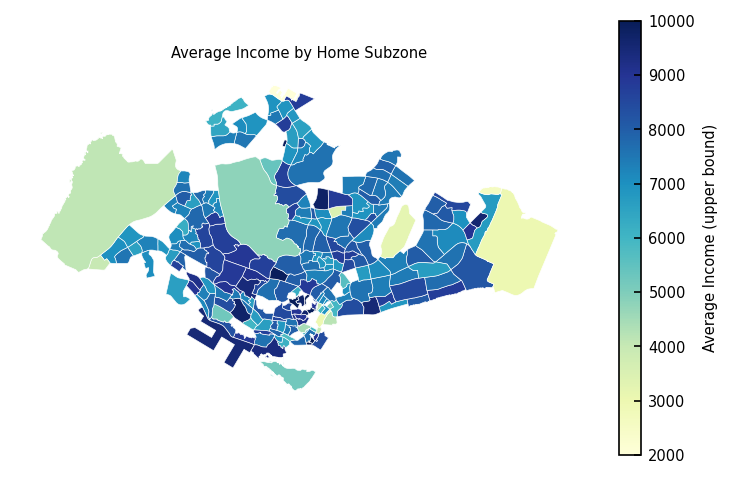

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import re

# ---------------------------------------------------------
# 2. Preprocess the input DataFrame df
# ---------------------------------------------------------

# keep only positive income
df_valid = df[df["INCOME"] > 0].copy()
df_valid["income_num"] = df_valid["INCOME"]

# compute both count and mean per HOME_SUBZONE
df_stats = (
    df_valid.groupby("HOME_SUBZONE")
            .agg(count=("income_num", "size"),
                 avg_income=("income_num", "mean"))
            .reset_index()
)

# keep only subzones with at least 10 respondents
df_stats = df_stats[df_stats["count"] > 1]

# rename to match shapefile
df_stats = df_stats.rename(columns={"HOME_SUBZONE": "SUBZONE_C"})

# ---------------------------------------------------------
# 3. Load shapefile & merge
# ---------------------------------------------------------
gdf = gpd.read_file(path_data + 'data_sgp_subzone.shp')

# merge only avg_income (keep geometry)
gdf = gdf.merge(df_stats[["SUBZONE_C", "avg_income"]],
                on="SUBZONE_C", how="left")

# ---------------------------------------------------------
# 4. Apply Nature style
# ---------------------------------------------------------
def set_nature_style():
    plt.rcParams.update({
        "figure.dpi": 150, "savefig.dpi": 150,
        "font.family": "DejaVu Sans", "font.size": 7,
        "axes.labelsize": 7, "axes.titlesize": 7,
        "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
        "axes.linewidth": 0.8, "lines.linewidth": 1.0,
        "xtick.direction": "in", "ytick.direction": "in",
    })

set_nature_style()

# ---------------------------------------------------------
# 5. Plot the choropleth
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

vmin = gdf["avg_income"].min()
vmax = gdf["avg_income"].max()

im = gdf.plot(
    column="avg_income",
    cmap="YlGnBu",
    linewidth=0.3,
    ax=ax,
    edgecolor="white",
    legend=True,
    legend_kwds={"shrink": 0.5, "label": "Average Income (upper bound)"},
)

ax.set_title("Average Income by Home Subzone", pad=6)
ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv(path_data + 'data_sgp_hts_trip_check_shi.csv')
df = df[df['TRAVEL_MODE'] == 0]
df = df[df['TRIP_CNT'] == 1]

df = df[['ID', 'INCOME', 'HOME_SUBZONE']]
df = df[df['INCOME'] > 0]
df = df.drop_duplicates()
#print(df['INCOME'].value_counts())

print(df)


           ID  INCOME HOME_SUBZONE
4      100005    1999       BDSZ04
23     100016   10000       SESZ03
29     100025    9999       CLSZ03
60     100049    6999       WDSZ05
64     100052   10000       AMSZ08
...       ...     ...          ...
50594    9992   10000       PGSZ03
50619   99943   10000       SBSZ06
50645   99973    8999       BPSZ04
50646   99977   10000       BDSZ03
50663   99997    8999       YSSZ03

[3714 rows x 3 columns]


# =================================================

# Stage 1 Model Embeding

In [ ]:
# ============================================================
# Discrete-latent encoder-only fusion (non-param decoder)
#   + Embedding encoder (Φ = [D,S,E,C] integer indices)
#   + Sparse-per-Φ support for q(H|Φ)
# ============================================================

import os, math, json, re, random
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional, Callable

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 0) Utilities: feature builders & small helpers
# ------------------------------------------------------------

def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numerics to reduce RAM usage (simple & safe)."""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if pd.api.types.is_numeric_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.api.types.is_float_dtype(col_type):
                df[col] = pd.to_numeric(df[col], downcast='float')
            else:
                df[col] = pd.to_numeric(df[col], downcast='integer')
    end_mem = df.memory_usage().sum() / 1024**2
    # print(f"[reduce_mem] {start_mem:.2f} -> {end_mem:.2f} MB")
    return df

def distance(df, att):
    """Great-circle distance (km). att = [lon_o, lon_d, lat_o, lat_d] (deg)."""
    lon1 = np.radians(df[att[0]]); lon2 = np.radians(df[att[1]])
    lat1 = np.radians(df[att[2]]); lat2 = np.radians(df[att[3]])
    dlon = lon2 - lon1; dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371*2*np.arcsin(np.sqrt(a))

'''def land_use(df_hts_):
    """DESTINATION_SUBZONE -> LU_0..LU_5 from HTS destination-purpose frequencies."""
    df = df_hts_[['DESTINATION_SUBZONE','TRIP_PURPOSE']].copy()
    df['Numbers'] = 1.0
    df['Numbers'] = df.groupby(['DESTINATION_SUBZONE','TRIP_PURPOSE'])['Numbers'].transform('sum')
    df.drop_duplicates(inplace=True)
    df['Prob'] = df['Numbers'] / df['Numbers'].sum()
    df.drop(columns=['Numbers'], inplace=True)
    df['Prob_'] = df.groupby('DESTINATION_SUBZONE')['Prob'].transform('sum')
    df['Prob'] = df['Prob'] / df['Prob_']; df.drop(columns=['Prob_'], inplace=True)
    df_lu = df[['DESTINATION_SUBZONE']].drop_duplicates()
    for i in range(6):
        part = df[df['TRIP_PURPOSE']==i].drop(columns=['TRIP_PURPOSE']).rename(columns={'Prob':f'LU_{i}'})
        df_lu = pd.merge(df_lu, part, on='DESTINATION_SUBZONE', how='left')
    return df_lu.fillna(0.0)

def mode_share(df_hts_):
    """DESTINATION_SUBZONE -> TRANSIT_RATIO = P(TRAVEL_MODE==1 | dest)."""
    df = df_hts_[['DESTINATION_SUBZONE','TRAVEL_MODE']].copy()
    df['Numbers'] = 1.0
    df['Numbers'] = df.groupby(['DESTINATION_SUBZONE','TRAVEL_MODE'])['Numbers'].transform('sum')
    df.drop_duplicates(inplace=True)
    df['Prob'] = df['Numbers'] / df['Numbers'].sum()
    df.drop(columns=['Numbers'], inplace=True)
    df['Prob_'] = df.groupby('DESTINATION_SUBZONE')['Prob'].transform('sum')
    df['Prob'] = df['Prob'] / df['Prob_']; df.drop(columns=['Prob_'], inplace=True)
    df = df[df['TRAVEL_MODE']==1].rename(columns={'Prob':'TRANSIT_RATIO'}).drop(columns=['TRAVEL_MODE'])
    return df'''

def land_use(df_hts_, df_pcm_):
    """DESTINATION_SUBZONE -> LU_0..LU_5. Fills missing PCM zones with HTS global averages."""
    # 1. Calculate probabilities from HTS
    df = df_hts_[['DESTINATION_SUBZONE','TRIP_PURPOSE']].copy()
    df['Numbers'] = 1.0
    df = df.groupby(['DESTINATION_SUBZONE','TRIP_PURPOSE'])['Numbers'].sum().reset_index()

    # Normalize per zone
    df['Zone_Total'] = df.groupby('DESTINATION_SUBZONE')['Numbers'].transform('sum')
    df['Prob'] = df['Numbers'] / df['Zone_Total']

    # Pivot to LU_0...LU_5
    df_lu = df.pivot(index='DESTINATION_SUBZONE', columns='TRIP_PURPOSE', values='Prob').reset_index()
    df_lu.columns.name = None
    df_lu = df_lu.rename(columns={i: f'LU_{i}' for i in range(6)})
    df_lu = df_lu.fillna(0.0)

    # 2. Handle missing zones using PCM universe
    pcm_zones = pd.DataFrame({'DESTINATION_SUBZONE': df_pcm_['DESTINATION_SUBZONE'].unique()})
    df_final = pd.merge(pcm_zones, df_lu, on='DESTINATION_SUBZONE', how='left')

    # 3. Fill NaNs with the average of existing zones
    lu_cols = [f'LU_{i}' for i in range(6)]
    avg_values = df_lu[lu_cols].mean()
    df_final[lu_cols] = df_final[lu_cols].fillna(avg_values)

    return df_final

def mode_share(df_hts_, df_pcm_):
    """DESTINATION_SUBZONE -> TRANSIT_RATIO. Fills missing PCM zones with global HTS mean."""
    # 1. Calculate transit ratio per zone from HTS
    df = df_hts_[['DESTINATION_SUBZONE','TRAVEL_MODE']].copy()
    df['is_transit'] = (df['TRAVEL_MODE'] == 1).astype(float)

    # Group by zone and get mean (which is the probability P(mode=1|zone))
    df_ms = df.groupby('DESTINATION_SUBZONE')['is_transit'].mean().reset_index()
    df_ms.rename(columns={'is_transit': 'TRANSIT_RATIO'}, inplace=True)

    # 2. Handle missing zones using PCM universe
    pcm_zones = pd.DataFrame({'DESTINATION_SUBZONE': df_pcm_['DESTINATION_SUBZONE'].unique()})
    df_final = pd.merge(pcm_zones, df_ms, on='DESTINATION_SUBZONE', how='left')

    # 3. Fill NaNs with the global average transit ratio from known zones
    global_avg = df_ms['TRANSIT_RATIO'].mean()
    df_final['TRANSIT_RATIO'] = df_final['TRANSIT_RATIO'].fillna(global_avg)

    return df_final

# ------------------------------------------------------------
# 0.1) Discrete-Φ helpers (bins + clusters → indices)
# ------------------------------------------------------------

@dataclass
class DiscreteSpec:
    n_dist: int = 6
    n_start: int = 8
    n_end: int = 8
    n_lu_mode_clusters: int = 16
    dist_binning: str = "quantile"  # or "uniform"
    time_binning: str = "quantile"  # or "uniform"

def _fit_bins(x: np.ndarray, n: int, kind: str) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if kind == "uniform":
        lo, hi = np.nanmin(x), np.nanmax(x)
        edges = np.linspace(lo, hi, n + 1)
    else:
        qs = np.linspace(0, 100, n + 1)
        edges = np.percentile(x, qs)
        edges[0]  = min(edges[0],  x.min()) - 1e-9
        edges[-1] = max(edges[-1], x.max()) + 1e-9
    return edges

def _digitize(x: np.ndarray, edges: np.ndarray) -> np.ndarray:
    return np.clip(np.digitize(x, edges, right=False) - 1, 0, len(edges) - 2)

def fit_semantic_spec_on_hts(
    df_hts: pd.DataFrame,
    spec: DiscreteSpec,
    distance_col="TRIP_DISTANCE",
    start_col="TRIP_STARTTIME",
    end_col="TRIP_ENDTIME",
    lu_cols=("LU_0","LU_1","LU_2","LU_3","LU_4","LU_5"),
    tr_col="TRANSIT_RATIO",
    km_random_state=42
) -> Dict:
    dist_edges  = _fit_bins(df_hts[distance_col].values, spec.n_dist,  spec.dist_binning)
    start_edges = _fit_bins(df_hts[start_col].values,   spec.n_start, spec.time_binning)
    end_edges   = _fit_bins(df_hts[end_col].values,     spec.n_end,   spec.time_binning)

    feat_cols = list(lu_cols) + [tr_col]
    X = df_hts[feat_cols].to_numpy(dtype=float)

    eps = 1e-8
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0)
    sd = np.where(sd < eps, 1.0, sd)
    Xz = (X - mu) / sd

    kmeans = KMeans(n_clusters=spec.n_lu_mode_clusters, n_init="auto", random_state=km_random_state)
    kmeans.fit(Xz)

    return {
        "dist_edges": dist_edges.tolist(),
        "start_edges": start_edges.tolist(),
        "end_edges": end_edges.tolist(),
        "lu_cols": list(lu_cols),
        "tr_col": tr_col,
        "lu_norm": {"mean": mu.tolist(), "std": sd.tolist(), "eps": eps, "feat_order": feat_cols},
        "kmeans_centers": kmeans.cluster_centers_.tolist(),
        "phi_segments": {
            "n_dist": spec.n_dist,
            "n_start": spec.n_start,
            "n_end": spec.n_end,
            "n_cluster": spec.n_lu_mode_clusters
        }
    }

def apply_semantic_spec(
    df: pd.DataFrame,
    fitted: Dict,
    distance_col="TRIP_DISTANCE",
    start_col="TRIP_STARTTIME",
    end_col="TRIP_ENDTIME"
) -> pd.DataFrame:
    df = df.copy()
    dist_edges  = np.array(fitted["dist_edges"], dtype=float)
    start_edges = np.array(fitted["start_edges"], dtype=float)
    end_edges   = np.array(fitted["end_edges"], dtype=float)

    d_bin = _digitize(df[distance_col].to_numpy(dtype=float), dist_edges)
    s_bin = _digitize(df[start_col].to_numpy(dtype=float),    start_edges)
    e_bin = _digitize(df[end_col].to_numpy(dtype=float),      end_edges)

    lu_meta = fitted["lu_norm"]
    feat_cols = lu_meta["feat_order"]
    mu = np.array(lu_meta["mean"], dtype=float)
    sd = np.array(lu_meta["std"], dtype=float)
    eps = float(lu_meta.get("eps", 1e-8))

    X = df[feat_cols].to_numpy(dtype=float)
    sd_safe = np.where(sd < eps, 1.0, sd)
    Xz = (X - mu) / sd_safe

    centers = np.array(fitted["kmeans_centers"], dtype=float)
    d2 = ((Xz[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    c_id = d2.argmin(axis=1)

    df["D_BIN"] = d_bin.astype(int)
    df["S_BIN"] = s_bin.astype(int)
    df["E_BIN"] = e_bin.astype(int)
    df["C_ID"]  = c_id.astype(int)
    return df

def build_phi_indices_from_bins(
    df: pd.DataFrame,
    cols=("D_BIN","S_BIN","E_BIN","C_ID")
) -> Tuple[pd.DataFrame, int]:
    """Store Φ as integer indices [D,S,E,C]."""
    df = df.copy()
    D = df[cols[0]].astype(int).to_numpy()
    S = df[cols[1]].astype(int).to_numpy()
    E = df[cols[2]].astype(int).to_numpy()
    C = df[cols[3]].astype(int).to_numpy()
    df["PHI_IDX"] = [[int(D[i]), int(S[i]), int(E[i]), int(C[i])] for i in range(len(df))]
    return df, 4  # four categorical fields

# ------------------------------------------------------------
# 1) Data containers (index-based Φ)
# ------------------------------------------------------------

class HTSDataset(Dataset):
    """One HTS row = (phi_idx[4], xy_id)."""
    def __init__(self, df_hts: pd.DataFrame, xy_ids: np.ndarray):
        self.phi_idx = np.vstack(df_hts["PHI_IDX"].to_numpy()).astype(np.int64)  # [N,4]
        self.xy = xy_ids.astype(np.int64)
    def __len__(self): return self.phi_idx.shape[0]
    def __getitem__(self, i):
        return self.phi_idx[i], self.xy[i]

class PCMDataset(Dataset):
    """One PCM row = (phi_idx[4], count)."""
    def __init__(self, df_pcm: pd.DataFrame):
        self.phi_idx = np.vstack(df_pcm["PHI_IDX"].to_numpy()).astype(np.int64)  # [N,4]
        self.count = df_pcm["COUNT"].to_numpy(dtype=np.float32)
    def __len__(self): return self.phi_idx.shape[0]
    def __getitem__(self, i):
        return self.phi_idx[i], self.count[i]

# ------------------------------------------------------------
# 2) Embedding Encoder (Φ indices -> embeddings -> MLP -> logits[K])
# ------------------------------------------------------------

class EncoderEmbed(nn.Module):
    """
    Embedding encoder: [D,S,E,C] indices -> concat(emb_D, emb_S, emb_E, emb_C) -> MLP -> logits[K].
    """
    def __init__(
        self,
        cardinals: Tuple[int, int, int, int],  # (n_dist, n_start, n_end, n_cluster)
        K: int,
        emb_dims: Tuple[int, int, int, int] = (16, 16, 16, 16),
        hidden: int = 256,
        num_layers: int = 2,
        dropout: float = 0.0
    ):
        super().__init__()
        nD, nS, nE, nC = map(int, cardinals)
        eD, eS, eE, eC = emb_dims

        self.emb_D = nn.Embedding(nD, eD)
        self.emb_S = nn.Embedding(nS, eS)
        self.emb_E = nn.Embedding(nE, eE)
        self.emb_C = nn.Embedding(nC, eC)

        in_dim = eD + eS + eE + eC
        layers: List[nn.Module] = []
        dims = [in_dim] + [hidden]*(num_layers-1) + [K]
        for i in range(len(dims)-2):
            layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU(inplace=True)]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
        layers += [nn.Linear(dims[-2], dims[-1])]
        self.net = nn.Sequential(*layers)

    def forward(self, phi_idx: torch.Tensor) -> torch.Tensor:
        """
        phi_idx: LongTensor [B,4] with columns [D,S,E,C].
        returns logits [B,K]
        """
        D = phi_idx[:, 0]; S = phi_idx[:, 1]; E = phi_idx[:, 2]; C = phi_idx[:, 3]
        z = torch.cat([self.emb_D(D), self.emb_S(S), self.emb_E(E), self.emb_C(C)], dim=-1)
        return self.net(z)

# ------------------------------------------------------------
# 3) Numerics, schedules, divergences, masked softmax
# ------------------------------------------------------------

def safe_log(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return torch.log(x.clamp_min(eps))

def entropy_categorical(probs: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return -(probs * safe_log(probs, eps)).sum(dim=-1)

def js_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    p = p / p.sum().clamp_min(eps)
    q = q / q.sum().clamp_min(eps)
    m = 0.5 * (p + q)
    kl_pm = (p * (safe_log(p, eps) - safe_log(m, eps))).sum()
    kl_qm = (q * (safe_log(q, eps) - safe_log(m, eps))).sum()
    return 0.5 * (kl_pm + kl_qm)

def softmax_tau(logits: torch.Tensor, tau: float) -> torch.Tensor:
    return F.softmax(logits / max(tau, 1e-6), dim=-1)

def get_tau(ep: int, total_ep: int, tau_start: float, tau_end: float, schedule: str = "linear") -> float:
    if total_ep <= 1: return tau_end
    t = (ep - 1) / (total_ep - 1)  # 0..1
    if schedule == "linear":
        s = t
    elif schedule == "cosine":
        s = 0.5 * (1 - math.cos(math.pi * t))
    elif schedule == "exp":
        s = 1 - math.exp(-5 * t)
    else:
        s = t
    return (1 - s) * tau_start + s * tau_end

# ------------------------------------------------------------
# 3.1) Sparse support policies & masked softmax
# ------------------------------------------------------------

SupportPolicy = Callable[[torch.Tensor, Optional[torch.Tensor]], torch.Tensor]
# signature: mask = policy(logits, phi_idx_b) -> bool tensor [B,K], True = allowed

def masked_softmax(logits: torch.Tensor,
                   mask: torch.Tensor,
                   tau: float = 1.0,
                   eps: float = 1e-12) -> torch.Tensor:
    B, K = logits.shape
    scaled = logits / max(tau, 1e-6)
    scaled = scaled.masked_fill(~mask, -1e9)
    q = F.softmax(scaled, dim=-1)
    q = q * mask.float()
    z = q.sum(dim=-1, keepdim=True).clamp_min(eps)
    return q / z

def topk_support_policy(k: int) -> SupportPolicy:
    def policy(logits: torch.Tensor, phi_idx_b: Optional[torch.Tensor] = None) -> torch.Tensor:
        B, K = logits.shape
        k_eff = min(max(1, k), K)
        idx = torch.topk(logits, k=k_eff, dim=-1).indices
        mask = torch.zeros_like(logits, dtype=torch.bool)
        mask.scatter_(1, idx, True)
        return mask
    return policy

def prob_threshold_policy(thr: float) -> SupportPolicy:
    def policy(logits: torch.Tensor, phi_idx_b: Optional[torch.Tensor] = None) -> torch.Tensor:
        p = F.softmax(logits, dim=-1)
        return p >= thr
    return policy

# ---- Bucketed support mining (index-based) ----

from collections import defaultdict

def build_phi_bucket_candidates_embed(
    encoder: nn.Module,
    hts_loader: DataLoader,
    K: int,
    tau: float,
    topk: int = 8,
    device: Optional[str] = None
) -> Dict[Tuple[int, int, int, int], np.ndarray]:
    """Aggregate q(H|Φ) over HTS and keep top-k H per Φ bucket. Φ is [D,S,E,C] indices."""
    enc_device = next(encoder.parameters()).device if device is None else torch.device(device)
    encoder.eval()
    acc = defaultdict(lambda: np.zeros(K, dtype=np.float64))

    with torch.no_grad():
        for phi_idx_b, _ in hts_loader:
            phi_idx_b = phi_idx_b.to(enc_device)              # [B,4] long
            logits = encoder(phi_idx_b)                       # [B,K]
            q = F.softmax(logits / max(tau, 1e-6), dim=-1).cpu().numpy()
            key_rows = phi_idx_b.cpu().numpy()                # [[D,S,E,C], ...]
            for i in range(key_rows.shape[0]):
                key = tuple(int(x) for x in key_rows[i])
                acc[key] += q[i]

    out = {}
    for key, vec in acc.items():
        k_eff = min(max(1, topk), K)
        keep = np.argpartition(-vec, k_eff-1)[:k_eff]
        keep = keep[np.argsort(-vec[keep])]
        out[key] = keep
    return out

def bucket_support_policy_embed(
    candidates: Dict[Tuple[int,int,int,int], np.ndarray]
) -> SupportPolicy:
    def policy(logits: torch.Tensor, phi_idx_b: Optional[torch.Tensor]) -> torch.Tensor:
        device = logits.device
        B, K = logits.shape
        mask = torch.zeros((B, K), dtype=torch.bool, device=device)
        keys = phi_idx_b.tolist()  # list of [D,S,E,C]
        for i in range(B):
            key = tuple(int(x) for x in keys[i])
            keep = candidates.get(key)
            if keep is None or len(keep) == 0:
                j = int(torch.argmax(logits[i]))
                mask[i, j] = True
            else:
                idx = torch.as_tensor(keep, dtype=torch.long, device=device)
                mask[i, idx] = True
        return mask
    return policy

# ------------------------------------------------------------
# 4) Non-param decoder  \hat{P}(XY|H)  (masked)
# ------------------------------------------------------------

@torch.no_grad()
def build_nonparam_decoder_xy_given_h(
    encoder: nn.Module,
    hts_loader: DataLoader,
    n_xy: int,
    K: int,
    device: str = "cpu",
    dtype: torch.dtype = torch.float32,
    progress: bool = True,
    tau: float = 1.0,
    support_policy: Optional[SupportPolicy] = None
) -> torch.Tensor:
    """
    \hat P(XY=j | H=h) = E[ 1{XY=j} q(h|Phi) ] / E[ q(h|Phi) ], with q masked per Φ (indices).
    Returns CPU tensor [n_xy, K] with columns summing to 1 (over kept H).
    """
    encoder.eval()
    num = torch.zeros((n_xy, K), dtype=dtype, device="cpu")
    den = torch.zeros((K,), dtype=dtype, device="cpu")

    for bi, (phi_idx_b, xy_b) in enumerate(hts_loader):
        if progress and bi % 50 == 0:
            print(f"[decoder] pass chunk {bi}")
        phi_idx_b = phi_idx_b.to(device=device, dtype=torch.long)
        logits = encoder(phi_idx_b)
        if support_policy is None:
            q = softmax_tau(logits, tau)
        else:
            mask = support_policy(logits, phi_idx_b)
            q = masked_softmax(logits, mask, tau)
        q = q.to("cpu")
        xy_b = xy_b.to("cpu")

        num.index_add_(0, xy_b, q)
        den += q.sum(dim=0)

    P = torch.zeros_like(num)
    mask = den > 0
    if mask.any():
        P[:, mask] = num[:, mask] / den[mask]
    P = P / P.sum(dim=0, keepdim=True).clamp_min(1e-12)
    return P

# ------------------------------------------------------------
# 5) Loss components (masked q everywhere)
# ------------------------------------------------------------

def compute_hts_nll(
    encoder: nn.Module,
    hts_loader: DataLoader,
    P_xy_given_h: torch.Tensor,
    log_norm: float,
    device: str,
    dtype: torch.dtype,
    progress: bool = True,
    tau: float = 1.0,
    support_policy: Optional[SupportPolicy] = None,
):
    total_nll = torch.zeros((), device=device, dtype=dtype)
    totalN = 0
    P_xy_given_h = P_xy_given_h.to(device=device, dtype=dtype)

    for bi, (phi_idx_b, xy_b) in enumerate(hts_loader):
        if progress and bi % 50 == 0:
            print(f"[hts-nll] pass chunk {bi}")
        B = phi_idx_b.shape[0]
        phi_idx_b = phi_idx_b.to(device=device, dtype=torch.long)
        xy_b  = xy_b.to(device=device, dtype=torch.long)

        logits = encoder(phi_idx_b)
        if support_policy is None:
            q = softmax_tau(logits, tau)
        else:
            mask = support_policy(logits, phi_idx_b)
            q = masked_softmax(logits, mask, tau)

        P_rows = P_xy_given_h.index_select(0, xy_b)    # [B, K]
        mix = (q * P_rows).sum(dim=-1).clamp_min(1e-12)
        nll_sum = -torch.log(mix).sum()

        total_nll = total_nll + nll_sum
        totalN += B

    avg_nll = total_nll / max(totalN, 1)
    if log_norm > 0:
        avg_nll = avg_nll / log_norm
    return avg_nll, totalN

def compute_latent_marginals(
    encoder: nn.Module,
    loader: DataLoader,
    K: int,
    device: str,
    dtype: torch.dtype,
    progress: bool = True,
    tau: float = 1.0,
    support_policy: Optional[SupportPolicy] = None,
):
    acc = torch.zeros(K, device=device, dtype=dtype)
    wsum = torch.zeros((), device=device, dtype=dtype)

    for bi, batch in enumerate(loader):
        if progress and bi % 50 == 0:
            print(f"[latent-marg] pass chunk {bi}")
        if len(batch) == 2:
            phi_idx_b, w_b = batch
            # HTS loader provides xy_b here; PCM loader provides COUNT; we handle both
            if w_b.dtype == torch.long or w_b.dtype == torch.int64:
                w_b = None
            else:
                w_b = w_b.to(device=device, dtype=dtype)
        else:
            phi_idx_b = batch[0]
            w_b = None

        phi_idx_b = phi_idx_b.to(device=device, dtype=torch.long)
        logits = encoder(phi_idx_b)
        if support_policy is None:
            q = softmax_tau(logits, tau)
        else:
            mask = support_policy(logits, phi_idx_b)
            q = masked_softmax(logits, mask, tau)

        if w_b is None:
            acc  = acc  + q.sum(dim=0)
            wsum = wsum + torch.tensor(q.shape[0], device=device, dtype=dtype)
        else:
            acc  = acc  + (q * w_b.unsqueeze(-1)).sum(dim=0)
            wsum = wsum + w_b.sum()

    p = acc / wsum.clamp_min(1e-12)
    p = p / p.sum().clamp_min(1e-12)
    return p

def compute_fusion_js(
    encoder: nn.Module,
    hts_loader: DataLoader,
    pcm_loader: DataLoader,
    K: int,
    device: str,
    dtype: torch.dtype,
    use_normalized: bool = True,
    tau: float = 1.0,
    support_policy: Optional[SupportPolicy] = None,
):
    p_hts = compute_latent_marginals(encoder, hts_loader, K, device, dtype, progress=False, tau=tau, support_policy=support_policy)
    p_pcm = compute_latent_marginals(encoder, pcm_loader, K, device, dtype, progress=False, tau=tau, support_policy=support_policy)
    m = 0.5 * (p_hts + p_pcm)
    js = 0.5 * (
        (p_hts * (torch.log(p_hts.clamp_min(1e-12)) - torch.log(m.clamp_min(1e-12)))).sum()
      + (p_pcm * (torch.log(p_pcm.clamp_min(1e-12)) - torch.log(m.clamp_min(1e-12)))).sum()
    )
    return js / math.log(2.0) if use_normalized else js

# ------------------------------------------------------------
# 6) Config
# ------------------------------------------------------------

@dataclass
class TrainConfig:
    K: int = 64
    enc_hidden: int = 256
    enc_layers: int = 2
    enc_dropout: float = 0.0
    epochs: int = 10
    batch_size_hts: int = 8192
    batch_size_pcm: int = 16384
    lr: float = 2e-3
    wd: float = 1e-4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_normalized_objective: bool = True
    lambda_fus: float = 1.0
    dtype: torch.dtype = torch.float32
    rebuild_every: int = 1
    progress: bool = True

    # softmax temperature annealing
    tau_start: float = 1.0
    tau_end:   float = 0.3
    tau_schedule: str = "cosine"

    # support policy controls
    topk_h: int = 8                   # per-Φ top-k for q(H|Φ)
    use_bucket_candidates: bool = False
    bucket_topk: int = 8
    refresh_bucket_every: int = 2     # epochs; 0 disables refresh

# ------------------------------------------------------------
# 7) Training loops (masked)
# ------------------------------------------------------------

def _prepare_xy_and_loaders(df_hts: pd.DataFrame,
                            df_pcm: pd.DataFrame,
                            cfg: TrainConfig):
    att_xy_series = (df_hts["ATT_X"].astype(str) + "|" + df_hts["ATT_Y"].astype(str))
    xy_vals = att_xy_series.to_numpy()
    xy_unique = pd.unique(xy_vals)
    xy_map = {k: i for i, k in enumerate(xy_unique)}
    xy_ids = np.vectorize(xy_map.__getitem__)(xy_vals)
    xy_classes = list(xy_unique)
    n_xy = len(xy_classes)

    hts_ds = HTSDataset(df_hts, xy_ids)
    pcm_ds = PCMDataset(df_pcm)
    hts_loader_full = DataLoader(hts_ds, batch_size=cfg.batch_size_hts, shuffle=False, num_workers=0, pin_memory=False)
    pcm_loader_full = DataLoader(pcm_ds, batch_size=cfg.batch_size_pcm, shuffle=False, num_workers=0, pin_memory=False)
    phi_dim = 4  # indices length, not used by embedding encoder
    return n_xy, xy_map, xy_classes, hts_loader_full, pcm_loader_full, phi_dim

def _make_support_policy(enc: nn.Module,
                         hts_loader_full: DataLoader,
                         tau: float,
                         cfg: TrainConfig) -> SupportPolicy:
    if cfg.use_bucket_candidates:
        cands = build_phi_bucket_candidates_embed(
            enc, hts_loader_full, cfg.K, tau,
            topk=cfg.bucket_topk, device=cfg.device
        )
        return bucket_support_policy_embed(cands)
    else:
        return topk_support_policy(cfg.topk_h)

def train_encoder_only_fusion(
    df_hts: pd.DataFrame,
    df_pcm: pd.DataFrame,                 # kept for signature parity
    cfg: TrainConfig,
    phi_segments_meta: Dict[str,int]      # pass fitted["phi_segments"]
) -> Dict:
    device = cfg.device
    dtype = cfg.dtype

    n_xy, xy_map, xy_classes, hts_loader_full, _pcm_loader_full, phi_dim = _prepare_xy_and_loaders(df_hts, df_pcm, cfg)

    # Embedding encoder
    cardinals = (phi_segments_meta["n_dist"], phi_segments_meta["n_start"],
                 phi_segments_meta["n_end"],  phi_segments_meta["n_cluster"])
    enc = EncoderEmbed(
        cardinals=cardinals, K=cfg.K,
        emb_dims=(16,16,16,16),
        hidden=cfg.enc_hidden, num_layers=cfg.enc_layers, dropout=cfg.enc_dropout
    ).to(device=device, dtype=torch.float32)
    opt = torch.optim.AdamW(enc.parameters(), lr=cfg.lr, weight_decay=cfg.wd)

    logXY = math.log(max(n_xy, 2))

    # Initial tau and support policy
    tau = get_tau(1, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
    support_policy = _make_support_policy(enc, hts_loader_full, tau, cfg)

    # Initial non-param decoder
    P_xy_h = build_nonparam_decoder_xy_given_h(
        encoder=enc, hts_loader=hts_loader_full, n_xy=n_xy, K=cfg.K,
        device=device, dtype=dtype, progress=cfg.progress, tau=tau,
        support_policy=support_policy
    )  # CPU [n_xy, K]

    history = []
    for ep in range(1, cfg.epochs + 1):
        tau = get_tau(ep, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
        enc.train(); opt.zero_grad()

        # Optionally refresh bucket candidates (EM-style)
        if cfg.use_bucket_candidates and cfg.refresh_bucket_every > 0 and (ep == 1 or (ep % cfg.refresh_bucket_every) == 0):
            support_policy = _make_support_policy(enc, hts_loader_full, tau, cfg)

        # (A) HTS NLL only
        L_hts, _ = compute_hts_nll(
            encoder=enc, hts_loader=hts_loader_full,
            P_xy_given_h=P_xy_h,
            log_norm=(logXY if cfg.use_normalized_objective else 1.0),
            device=device, dtype=dtype, progress=cfg.progress, tau=tau,
            support_policy=support_policy
        )

        total = L_hts
        total.backward()
        opt.step()

        # (B) Rebuild decoder periodically with current tau + support
        if (ep % cfg.rebuild_every) == 0:
            P_xy_h = build_nonparam_decoder_xy_given_h(
                encoder=enc, hts_loader=hts_loader_full, n_xy=n_xy, K=cfg.K,
                device=device, dtype=dtype, progress=cfg.progress, tau=tau,
                support_policy=support_policy
            )

        metrics = {
            "epoch": ep,
            "tau": float(tau),
            "L_hts": float(L_hts.detach().cpu().item()),
            "J_total": float(total.detach().cpu().item()),
        }
        history.append(metrics)
        print(f"[epoch {ep:03d}] tau={tau:.4f}  L_hts={metrics['L_hts']:.6f}  total={metrics['J_total']:.6f}")

    # ===== Final evaluation with final tau + fresh support =====
    tau_final = get_tau(cfg.epochs, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
    support_policy = _make_support_policy(enc, hts_loader_full, tau_final, cfg)

    P_xy_h_final = build_nonparam_decoder_xy_given_h(
        encoder=enc, hts_loader=hts_loader_full, n_xy=n_xy, K=cfg.K,
        device=device, dtype=dtype, progress=cfg.progress, tau=tau_final,
        support_policy=support_policy
    )

    L_hts_final, _ = compute_hts_nll(
        encoder=enc, hts_loader=hts_loader_full, P_xy_given_h=P_xy_h_final,
        log_norm=(logXY if cfg.use_normalized_objective else 1.0),
        device=device, dtype=dtype, progress=False, tau=tau_final,
        support_policy=support_policy
    )

    J_final = float(L_hts_final.detach().cpu().item())
    print(f"[FINAL] K={cfg.K}  tau={tau_final:.4f}  L_hts={J_final:.6f}")

    pack = {
        "encoder_state_dict": enc.state_dict(),
        "encoder_cfg": {
            "cardinals": list(cardinals), "K": cfg.K, "hidden": cfg.enc_hidden,
            "layers": cfg.enc_layers, "dropout": cfg.enc_dropout, "dtype": str(dtype)
        },
        "xy_map": xy_map,
        "xy_classes": xy_classes,
        "P_xy_given_h": P_xy_h_final,         # CPU tensor [n_xy, K]
        "history": history,
        "config": cfg.__dict__,
        "tau_final": float(tau_final),
        "J_final": J_final,
        "L_hts_final": J_final,
        "phi_segments": dict(phi_segments_meta),
    }
    return {"model": enc, "pack": pack}

def train_encoder_only_fusion_finding_K(
    df_hts: pd.DataFrame,
    df_pcm: pd.DataFrame,
    cfg: TrainConfig,
    phi_segments_meta: Dict[str,int]
) -> Dict:
    device = cfg.device
    dtype = cfg.dtype

    # Prepare data/loaders
    n_xy, xy_map, xy_classes, hts_loader_full, pcm_loader_full, phi_dim = _prepare_xy_and_loaders(df_hts, df_pcm, cfg)

    # Build embedding encoder
    cardinals = (phi_segments_meta["n_dist"], phi_segments_meta["n_start"],
                 phi_segments_meta["n_end"],  phi_segments_meta["n_cluster"])
    enc = EncoderEmbed(
        cardinals=cardinals, K=cfg.K,
        emb_dims=(16,16,16,16),
        hidden=cfg.enc_hidden, num_layers=cfg.enc_layers, dropout=cfg.enc_dropout
    ).to(device=device, dtype=torch.float32)
    opt = torch.optim.AdamW(enc.parameters(), lr=cfg.lr, weight_decay=cfg.wd)

    logXY = math.log(max(n_xy, 2))

    # Init temperature + support policy
    tau = get_tau(1, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
    support_policy = _make_support_policy(enc, hts_loader_full, tau, cfg)

    # Initial non-parametric decoder P(XY|H)
    P_xy_h = build_nonparam_decoder_xy_given_h(
        encoder=enc, hts_loader=hts_loader_full, n_xy=n_xy, K=cfg.K,
        device=device, dtype=dtype, progress=cfg.progress, tau=tau,
        support_policy=support_policy
    )

    history = []
    for ep in range(1, cfg.epochs + 1):
        tau = get_tau(ep, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
        enc.train(); opt.zero_grad()

        # Optional refresh of Φ-bucket candidates
        if cfg.use_bucket_candidates and cfg.refresh_bucket_every > 0 and (ep == 1 or (ep % cfg.refresh_bucket_every) == 0):
            support_policy = _make_support_policy(enc, hts_loader_full, tau, cfg)

        # ---- Likelihood-only objective ----
        L_hts, _ = compute_hts_nll(
            encoder=enc, hts_loader=hts_loader_full,
            P_xy_given_h=P_xy_h,
            log_norm=(logXY if cfg.use_normalized_objective else 1.0),
            device=device, dtype=dtype, progress=cfg.progress, tau=tau,
            support_policy=support_policy
        )

        total = L_hts  # <-- only likelihood drives training
        total.backward()
        opt.step()

        # Periodically rebuild decoder with current encoder + tau + support
        if (ep % cfg.rebuild_every) == 0:
            P_xy_h = build_nonparam_decoder_xy_given_h(
                encoder=enc, hts_loader=hts_loader_full, n_xy=n_xy, K=cfg.K,
                device=device, dtype=dtype, progress=cfg.progress, tau=tau,
                support_policy=support_policy
            )

        metrics = {
            "epoch": ep,
            "tau": float(tau),
            "L_hts": float(L_hts.detach().cpu().item()),
            "J_total": float(total.detach().cpu().item()),  # equals L_hts
        }
        history.append(metrics)
        print(f"[epoch {ep:03d}] tau={tau:.4f}  L_hts={metrics['L_hts']:.6f}")

    # ===== Final evaluation =====
    tau_final = get_tau(cfg.epochs, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
    support_policy = _make_support_policy(enc, hts_loader_full, tau_final, cfg)

    # Final decoder
    P_xy_h_final = build_nonparam_decoder_xy_given_h(
        encoder=enc, hts_loader=hts_loader_full, n_xy=n_xy, K=cfg.K,
        device=device, dtype=dtype, progress=cfg.progress, tau=tau_final,
        support_policy=support_policy
    )

    # Final likelihood (objective)
    L_hts_final, _ = compute_hts_nll(
        encoder=enc, hts_loader=hts_loader_full, P_xy_given_h=P_xy_h_final,
        log_norm=(math.log(max(n_xy,2)) if cfg.use_normalized_objective else 1.0),
        device=device, dtype=dtype, progress=False, tau=tau_final,
        support_policy=support_policy
    )

    # Fusion consistency (post-hoc) = JS(p_HTS(H), p_PCM(H))
    L_fus_final = compute_fusion_js(
        encoder=enc, hts_loader=hts_loader_full, pcm_loader=pcm_loader_full,
        K=cfg.K, device=device, dtype=dtype,
        use_normalized=cfg.use_normalized_objective, tau=tau_final,
        support_policy=support_policy
    )

    # Print requested summaries
    print(f"[FINAL] K={cfg.K}  tau={tau_final:.4f}")
    print(f"        Final likelihood (HTS NLL): {float(L_hts_final):.6f}")
    print(f"        Fusion consistency (JS):    {float(L_fus_final):.6f}")

    pack = {
        "encoder_state_dict": enc.state_dict(),
        "encoder_cfg": {"cardinals": list(cardinals), "K": cfg.K, "hidden": cfg.enc_hidden,
                        "layers": cfg.enc_layers, "dropout": cfg.enc_dropout, "dtype": str(dtype)},
        "xy_map": xy_map,
        "xy_classes": xy_classes,
        "P_xy_given_h": P_xy_h_final,
        "history": history,
        "config": cfg.__dict__,
        "tau_final": float(tau_final),
        # store both metrics explicitly
        "L_hts_final": float(L_hts_final.detach().cpu().item()),
        "fusion_consistency_js": float(L_fus_final.detach().cpu().item()),
        "phi_segments": dict(phi_segments_meta),
    }
    return {"model": enc, "pack": pack}


# ------------------------------------------------------------
# 8) Decoder table -> DataFrame
# ------------------------------------------------------------

def pack_to_dataframe(pack: dict) -> pd.DataFrame:
    P_xy_h = pack["P_xy_given_h"]         # [n_xy, K] CPU torch.Tensor
    xy_classes = pack["xy_classes"]       # list of "ATT_X|ATT_Y"
    K = int(pack["encoder_cfg"]["K"])

    P = P_xy_h.detach().cpu().numpy()     # (n_xy, K)
    df = pd.DataFrame({"ATT_XY": xy_classes})
    h_cols = [f"H_{h}" for h in range(K)]
    df_probs = pd.DataFrame(P, columns=h_cols)
    df = pd.concat([df, df_probs], axis=1)
    df = df.melt(id_vars=["ATT_XY"], value_vars=h_cols,
                 var_name="H", value_name="PROB")
    df["H"] = df["H"].apply(lambda s: int(re.sub(r"^H_", "", s)))

    def split_att(x):
        parts = str(x).split("|", 1)
        if len(parts) == 2: return parts[0], parts[1]
        else: return parts[0], ""
    att = df["ATT_XY"].apply(split_att)
    df["ATT_X"] = att.apply(lambda t: t[0])
    df["ATT_Y"] = att.apply(lambda t: t[1])

    return df[["ATT_X", "ATT_Y", "H", "PROB"]].reset_index(drop=True)

# ------------------------------------------------------------
# 9) Latent diagnostics from q (supports sparsity via policies)
# ------------------------------------------------------------

def _latent_diagnostics_from_q(
    q_latent: np.ndarray,
    weights: Optional[np.ndarray],
    eps: float = 1e-12
) -> Dict[str, float]:
    N, K = q_latent.shape
    w = np.ones(N, dtype=np.float64) if weights is None else np.asarray(weights, dtype=np.float64)
    w = np.clip(w, 0.0, None)
    wsum = w.sum() + eps

    H = -(q_latent * np.log(np.clip(q_latent, eps, 1.0))).sum(axis=1)
    H_mean = float((H * w).sum() / wsum)
    H_norm = H_mean / math.log(K)

    p = (q_latent * w[:, None]).sum(axis=0) / wsum
    p = p / p.sum()
    H_marg = float(-(p * np.log(np.clip(p, eps, 1.0))).sum())
    I_est  = float(max(0.0, H_marg - H_mean))

    qmax = q_latent.max(axis=1)
    q2   = np.partition(q_latent, -2, axis=1)[:, -2]
    gap  = qmax - q2
    qmax_mean = float((qmax * w).sum() / wsum)
    gap_mean  = float((gap  * w).sum() / wsum)

    KL_qU_mean = float(math.log(K) - H_mean)
    KL_qU_norm = KL_qU_mean / math.log(K)

    winners = q_latent.argmax(axis=1)
    win_counts = np.bincount(winners, minlength=K).astype(np.float64)
    win_ratio_max = float(win_counts.max() / max(N, 1))

    return {
        "E[H(q)]": H_mean,
        "E[H(q)]/logK": H_norm,
        "H_marg": H_marg,
        "I_est = H(P) - E[H(q)]": I_est,
        "E[max q]": qmax_mean,
        "E[max-min2 gap]": gap_mean,
        "E[KL(q||U)]/logK": KL_qU_norm,
        "argmax_dominance_ratio": win_ratio_max,
        "K": float(K),
        "N": float(N),
    }

@torch.no_grad()
def _encode_q_from_df(
    df: 'pd.DataFrame',
    encoder: 'nn.Module',
    K: int,
    device: str,
    batch_size: int = 8192,
    tau: float = 1.0,
    weights_col: Optional[str] = None,
    support_policy: Optional[SupportPolicy] = None
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    weights = None
    if (weights_col is not None) and (weights_col in df.columns):
        weights = df[weights_col].to_numpy(dtype=np.float64)

    phi_np = np.vstack(df["PHI_IDX"].to_numpy()).astype(np.int64)
    N = phi_np.shape[0]
    q_blocks = []

    encoder.eval()
    for start in range(0, N, batch_size):
        end = min(N, start + batch_size)
        phi_b = torch.from_numpy(phi_np[start:end]).to(device=device, dtype=torch.long)
        logits = encoder(phi_b)
        if support_policy is None:
            q = softmax_tau(logits, tau)
        else:
            mask = support_policy(logits, phi_b)
            q = masked_softmax(logits, mask, tau)
        q_blocks.append(q.cpu().numpy())

    q_latent = np.vstack(q_blocks)
    return q_latent, weights

def uniformity_report_from_df(
    df_hts: 'pd.DataFrame',
    df_pcm: 'pd.DataFrame',
    encoder: 'nn.Module',
    pack: Dict,
    device: str,
    batch_size: int = 8192,
    tau: Optional[float] = None,
    support_policy: Optional[SupportPolicy] = None,
) -> Dict[str, Dict[str, float]]:
    if tau is None:
        tau = float(pack.get("tau_final", 1.0))
    K = int(pack["encoder_cfg"]["K"])

    q_hts, _ = _encode_q_from_df(df_hts, encoder, K, device, batch_size, tau, weights_col=None, support_policy=support_policy)
    rep_hts = _latent_diagnostics_from_q(q_hts, weights=None)

    wcol = "COUNT" if "COUNT" in df_pcm.columns else None
    q_pcm, w_pcm = _encode_q_from_df(df_pcm, encoder, K, device, batch_size, tau, weights_col=wcol, support_policy=support_policy)
    rep_pcm = _latent_diagnostics_from_q(q_pcm, weights=w_pcm)

    return {"HTS": rep_hts, "PCM": rep_pcm}

# ------------------------------------------------------------
# 10) Merge-based latent encoding for PCM (masked export)
# ------------------------------------------------------------

@torch.no_grad()
def encode_pcm_to_latent_df(
    df_pcm: pd.DataFrame,
    model: nn.Module,
    pack: Dict,
    device: str = "cpu",
    batch_size: int = 8192,
    tau: Optional[float] = None,
    topk_h: int = 2, # Ensure we use top-k to keep it sparse
    support_policy: Optional[SupportPolicy] = None
) -> pd.DataFrame: # Removed q_latent return to save RAM

    if tau is None:
        tau = float(pack.get("tau_final", 1.0))
    K = int(pack["encoder_cfg"]["K"])

    all_pcm_rows = []
    all_h_indices = []
    all_probs = []

    N = len(df_pcm)
    model.eval()

    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(N, start + batch_size)
            phi_b = np.vstack(df_pcm["PHI_IDX"].iloc[start:end].to_numpy()).astype(np.int64)
            phi_b = torch.from_numpy(phi_b).to(device=device, dtype=torch.long)

            logits = model(phi_b)
            if support_policy is None:
                q = softmax_tau(logits, tau)
            else:
                mask = support_policy(logits, phi_b)
                q = masked_softmax(logits, mask, tau)

            q_cpu = q.to("cpu").numpy().astype(np.float32) # Use float32

            # Efficiently extract top-k
            # Using argpartition is much faster than sorting the whole array
            for i in range(q_cpu.shape[0]):
                probs = q_cpu[i]
                k_eff = min(topk_h, K)

                # Get indices of top k probabilities
                keep = np.argpartition(-probs, k_eff-1)[:k_eff]
                # Sort them so the highest is first (optional but helpful)
                keep = keep[np.argsort(-probs[keep])]

                all_pcm_rows.extend([start + i] * k_eff)
                all_h_indices.extend(keep.tolist())
                all_probs.extend(probs[keep].tolist())

    # Build DataFrame directly from lists (more memory efficient than vstacking blocks)
    q_df = pd.DataFrame({
        "PCM_ROW": np.array(all_pcm_rows, dtype=np.int32),
        "H": np.array(all_h_indices, dtype=np.int32),
        "PROB": np.array(all_probs, dtype=np.float32)
    })

    return q_df


def encode_pcm_to_latent_df_noused(
    df_pcm: pd.DataFrame,
    model: nn.Module,
    pack: Dict,
    device: str = "cpu",
    batch_size: int = 8192,
    tau: Optional[float] = None,
    topk_h: Optional[int] = None,
    h_prob_threshold: Optional[float] = None,
    support_policy: Optional[SupportPolicy] = None
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Returns q_df columns: ["PCM_ROW","H","PROB"] where PROB = masked q_phi(H|Phi_row).
    If topk_h or threshold provided, additionally sparsifies the exported rows.
    """
    if tau is None:
        tau = float(pack.get("tau_final", 1.0))
    K = int(pack["encoder_cfg"]["K"])

    all_rows = []
    q_blocks = []

    N = len(df_pcm)
    model.eval()

    for start in range(0, N, batch_size):
        end = min(N, start + batch_size)
        phi_b = np.vstack(df_pcm["PHI_IDX"].iloc[start:end].to_numpy()).astype(np.int64)
        phi_b = torch.from_numpy(phi_b).to(device=device, dtype=torch.long)

        logits = model(phi_b)
        if support_policy is None:
            q = softmax_tau(logits, tau)
        else:
            mask = support_policy(logits, phi_b)
            q = masked_softmax(logits, mask, tau)

        q_cpu = q.to("cpu").numpy()
        q_blocks.append(q_cpu)

        B = q_cpu.shape[0]
        if (topk_h is None) and (h_prob_threshold is None):
            pcm_idx = np.repeat(np.arange(start, end), K)
            h_idx   = np.tile(np.arange(K), B)
            prob    = q_cpu.reshape(-1)
            block = np.column_stack([pcm_idx, h_idx, prob])
            all_rows.append(block)
        else:
            for i in range(B):
                probs = q_cpu[i]
                if h_prob_threshold is not None:
                    keep = np.where(probs >= h_prob_threshold)[0]
                    vals = probs[keep]
                else:
                    k = min(int(topk_h), K)
                    keep = np.argpartition(-probs, k-1)[:k]
                    keep = keep[np.argsort(-probs[keep])]
                    vals = probs[keep]
                pcm_row = start + i
                if len(keep) > 0:
                    block = np.column_stack([np.full_like(keep, pcm_row), keep, vals])
                    all_rows.append(block)

    q_latent = np.vstack(q_blocks) if len(q_blocks) > 0 else np.empty((0, K))
    if len(all_rows) == 0:
        q_df = pd.DataFrame(columns=["PCM_ROW", "H", "PROB"])
    else:
        arr = np.vstack(all_rows).astype(np.float64)
        q_df = pd.DataFrame(arr, columns=["PCM_ROW", "H", "PROB"]).astype(
            {"PCM_ROW": int, "H": int, "PROB": float}
        )
    return q_df, q_latent

# ------------------------------------------------------------
# 11) Optional: conditional filtering helper
# ------------------------------------------------------------

def filter_by_conditioned_probability(
    df: pd.DataFrame,
    att_cols: List[str],
    prob_col: str = "Prob_XYZ_fus",
    *,
    abs_threshold: float = 1e-4,
    min_group_sum: float = 1e-15,
    add_column_name: str = "P_cond",
    return_splits: bool = True,
    preserve: str = "group_then_global"  # {"group_then_global", "global_only", "none"}
) -> Tuple[pd.DataFrame, Optional[pd.DataFrame]]:
    """
    Filter by per-group conditional probability with an absolute threshold.

    Steps:
      1) Compute group sums and conditional prob: P_cond = prob / group_sum
      2) Keep rows with P_cond >= abs_threshold
      3) Renormalize P_cond within each group to sum to 1
      4) Preserve probability mass:
         - "group_then_global": restore original group mass, then global normalize
         - "global_only": only global normalize
         - "none": leave raw group mass as-is (after step 3)
    Returns:
      kept_df, dropped_df (or None if return_splits=False)
    """
    if preserve not in {"group_then_global", "global_only", "none"}:
        raise ValueError("preserve must be one of {'group_then_global','global_only','none'}")

    df = df.copy()

    # 1) Group totals and conditional probability
    group_sum_orig = (
        df.groupby(att_cols, dropna=False)[prob_col]
          .transform("sum")
          .clip(lower=min_group_sum)
    )
    df[add_column_name] = df[prob_col] / group_sum_orig

    # 2) Keep rows above absolute conditional threshold
    keep_mask = df[add_column_name] >= float(abs_threshold)
    kept = df[keep_mask].reset_index(drop=True)
    dropped = df[~keep_mask].reset_index(drop=True) if return_splits else None

    if kept.empty:
        return kept, dropped

    # 3) Renormalize conditional probabilities within each group
    group_sum_kept_cond = (
        kept.groupby(att_cols, dropna=False)[add_column_name]
            .transform("sum")
            .clip(lower=min_group_sum)
    )
    kept[add_column_name] = kept[add_column_name] / group_sum_kept_cond

    # 4) Preserve probability mass as requested
    if preserve == "group_then_global":
        # Restore each group's original mass
        group_mass = (
            df[att_cols + [prob_col]]
            .groupby(att_cols, dropna=False)[prob_col]
            .sum()
            .rename("_GROUP_MASS_ORIG")
            .reset_index()
        )
        kept = kept.merge(group_mass, on=att_cols, how="left")
        kept["_GROUP_MASS_ORIG"] = kept["_GROUP_MASS_ORIG"].fillna(0.0)
        kept[prob_col] = kept[add_column_name] * kept["_GROUP_MASS_ORIG"]
        kept.drop(columns=["_GROUP_MASS_ORIG"], inplace=True)

        # Global normalization (optional but common in probability tables)
        total = float(kept[prob_col].sum())
        if total > 0:
            kept[prob_col] = kept[prob_col] / total

    elif preserve == "global_only":
        total = float(kept[prob_col].sum())
        if total > 0:
            kept[prob_col] = kept[prob_col] / total

    else:
        # "none": leave as-is; prob_col unchanged except for earlier steps
        pass

    return kept, dropped



# ------------------------------------------------------------
# 11) Validation: Marginal Distribution Comparison
# ------------------------------------------------------------

def validate_z_marginals(df_fused: pd.DataFrame, df_pcm_orig: pd.DataFrame, att_z_cols: list):
    print("\n" + "="*50)
    print("VALIDATION: Marginal Distribution of Z (PCM)")
    print("="*50)

    # 1. Prepare Ground Truth from original PCM
    # We use the 'COUNT' column to represent the true distribution
    gt_z = df_pcm_orig.groupby(att_z_cols)['COUNT'].sum().reset_index()
    gt_z['P_Z_true'] = gt_z['COUNT'] / gt_z['COUNT'].sum()

    # 2. Prepare Fused Marginal
    fus_z = df_fused.groupby(att_z_cols)['Prob_XYZ_fus'].sum().reset_index()
    fus_z.rename(columns={'Prob_XYZ_fus': 'P_Z_fused'}, inplace=True)

    # 3. Merge for comparison
    comparison = pd.merge(gt_z, fus_z, on=att_z_cols, how='outer').fillna(0)

    # 4. Calculate Metrics
    # Total Variation Distance: 0.5 * sum|p - q|
    tvd = 0.5 * np.abs(comparison['P_Z_true'] - comparison['P_Z_fused']).sum()

    # Pearson Correlation
    corr = np.corrcoef(comparison['P_Z_true'], comparison['P_Z_fused'])[0, 1]

    # Print Results
    print(f"Total Unique Z-bins (Trips): {len(comparison)}")
    print(f"Total Variation Distance (TVD): {tvd:.6f}  (Ideal: 0.0)")
    print(f"Pearson Correlation:           {corr:.6f}  (Ideal: 1.0)")

    # Summary of Drift
    max_drift = (comparison['P_Z_true'] - comparison['P_Z_fused']).abs().max()
    print(f"Max Probability Drift:         {max_drift:.6e}")

    if tvd < 0.01:
        print("RESULT: SUCCESS - P(att_Z) is highly preserved.")
    else:
        print("RESULT: WARNING - Significant drift detected in Z-marginal.")


# Stage 1 Data fusion

In [ ]:
# ------------------------------------------------------------
# __main__: Example end-to-end run (adjust paths)
# ------------------------------------------------------------
import gc
import pandas as pd
from typing import List, Optional, Tuple
import time

if __name__ == "__main__":


    start_time = time.time()
    reg = 'sgp'

    # --- Load data ---
    df_hts = pd.read_csv(os.path.join(path_data, f"data_{reg}_hts_trip.csv"))
    df_pcm = pd.read_csv(os.path.join(path_data, f"data_{reg}_pcm_trip.csv"))

    # 1) Aggregate PCM counts per (O,D,start,end)
    if "COUNT" not in df_pcm.columns:
        df_pcm["COUNT"] = 1.0
        df_pcm["COUNT"] = df_pcm.groupby(
            ["ORIGIN_SUBZONE","DESTINATION_SUBZONE","TRIP_STARTTIME","TRIP_ENDTIME"]
        )["COUNT"].transform("sum")
        df_pcm = df_pcm.drop_duplicates()

    # 2) Base features for discretization
    df_hts["TRIP_DISTANCE"] = distance(df_hts, ['ORIGIN_SUBZONE_X','DESTINATION_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_Y'])
    df_pcm["TRIP_DISTANCE"] = distance(df_pcm, ['ORIGIN_SUBZONE_X','DESTINATION_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_Y'])
    df_land_use = land_use(df_hts, df_pcm) #check
    df_mode = mode_share(df_hts, df_pcm) #check
    df_hts = df_hts.merge(df_land_use, on='DESTINATION_SUBZONE').merge(df_mode, on='DESTINATION_SUBZONE')
    df_pcm = df_pcm.merge(df_land_use, on='DESTINATION_SUBZONE').merge(df_mode, on='DESTINATION_SUBZONE')

    # 3) Φ (DISCRETE): fit on HTS and apply to HTS/PCM, then store indices
    nb = 20 # 10
    spec = DiscreteSpec(n_dist=nb, n_start=nb, n_end=nb, n_lu_mode_clusters=nb,
                        dist_binning="uniform", time_binning="uniform")

    fitted = fit_semantic_spec_on_hts(df_hts, spec)
    df_hts = apply_semantic_spec(df_hts, fitted)
    df_pcm = apply_semantic_spec(df_pcm, fitted)

    # Use the stored segment sizes so bucket policies work later
    phi_segments_meta = fitted["phi_segments"]
    n_d = phi_segments_meta["n_dist"]
    n_s = phi_segments_meta["n_start"]
    n_e = phi_segments_meta["n_end"]
    n_c = phi_segments_meta["n_cluster"]

    df_hts, phi_dim = build_phi_indices_from_bins(df_hts)
    df_pcm, _       = build_phi_indices_from_bins(df_pcm)

    # 4) Attributes (X,Y,Z) and stringified ATT_X, ATT_Y (for XY classes)
    att_X = ['AGE','GENDER']  # ,'INCOME'
    att_Y = ['TRIP_CNT','TRIP_MAX','TRIP_PURPOSE','TRAVEL_MODE']
    att_Z = ['ORIGIN_SUBZONE','DESTINATION_SUBZONE','TRIP_STARTTIME','TRIP_ENDTIME',
             'ORIGIN_SUBZONE_X','DESTINATION_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_Y']

    df_hts = df_hts[att_X + att_Y + att_Z + ['PHI_IDX']]
    df_pcm = df_pcm[att_Z + ['PHI_IDX','COUNT']]

    df_hts['ATT_X'] = df_hts[att_X].astype(str).apply('_'.join, axis=1)
    df_hts['ATT_Y'] = df_hts[att_Y].astype(str).apply('_'.join, axis=1)
    df_hts['ATT_Z'] = df_hts[att_Z].astype(str).apply('_'.join, axis=1)
    df_pcm['ATT_Z'] = df_pcm[att_Z].astype(str).apply('_'.join, axis=1)

    df_hts = reduce_mem_usage(df_hts)
    df_pcm = reduce_mem_usage(df_pcm)

    KK = 3000 #3000
    # 5) Train with sparse per-Φ support (embedding encoder)
    cfg = TrainConfig(
        K=KK,                       # large K is fine with embeddings 3000
        enc_hidden=256,
        enc_layers=2,
        enc_dropout=0.0,
        epochs=5,
        batch_size_hts=8192,
        batch_size_pcm=16384,
        lr=2e-3,
        wd=1e-4,
        device=("cuda" if torch.cuda.is_available() else "cpu"),
        use_normalized_objective=True,
        rebuild_every=1,
        progress=True,
        tau_start=0.01,
        tau_end=0.01,
        tau_schedule="cosine",

        topk_h=10,
        use_bucket_candidates=False,
        # bucket_topk=8,
        # refresh_bucket_every=2
    )

    out = train_encoder_only_fusion(df_hts, df_pcm, cfg, phi_segments_meta)
    model, pack = out["model"], out["pack"]

    # 6) Build the decoder table once after training
    decoder_df = pack_to_dataframe(pack).copy()   # ["ATT_X","ATT_Y","H","PROB"]
    # Threshold + renormalize within latent state H
    decoder_df = decoder_df[decoder_df['PROB'] > 1e-4] #1e-3
    sum_h = decoder_df.groupby('H', observed=True)['PROB'].transform('sum')
    decoder_df = decoder_df[sum_h > 0]
    decoder_df['PROB'] = decoder_df['PROB'] / sum_h[sum_h > 0]
    decoder_df.rename(columns={'PROB': 'PROB_XY|H'}, inplace=True)

    # 7) Prepare the SAME support policy for inference/merging
    tau_eval = float(pack.get("tau_final", 1.0))

    if cfg.use_bucket_candidates:
        phi_hts = torch.from_numpy(np.vstack(df_hts["PHI_IDX"].to_numpy()).astype(np.int64))
        dummy_y = torch.zeros((phi_hts.shape[0],), dtype=torch.long)
        hts_phi_loader = DataLoader(TensorDataset(phi_hts, dummy_y),
                                    batch_size=cfg.batch_size_hts, shuffle=False, num_workers=0)
        cand_map = build_phi_bucket_candidates_embed(
            model, hts_phi_loader, cfg.K, tau_eval,
            topk=cfg.bucket_topk, device=cfg.device
        )
        support_policy_infer = bucket_support_policy_embed(cand_map)
    else:
        support_policy_infer = topk_support_policy(cfg.topk_h)

    # 8) Encode PCM to latent with the same support policy
    q_df = encode_pcm_to_latent_df(
        df_pcm=df_pcm,
        model=model,
        pack=pack,
        device=cfg.device,
        batch_size=8192,
        tau=tau_eval,
        topk_h=2,                      # optional export sparsification
        support_policy=support_policy_infer
    )
    q_df.rename(columns={'PROB': 'PROB_H'}, inplace=True)
    # Renormalize within each PCM row so sum_H q(H|Phi_row) = 1
    sum_row = q_df.groupby('PCM_ROW', observed=True)['PROB_H'].transform('sum')
    q_df = q_df[sum_row > 0].copy()
    q_df['PROB_H'] = q_df['PROB_H'] / sum_row[sum_row > 0]


    # 9) Merge for fused probabilities

    # 1. Prepare PCM and HTS data components
    df_fus_pcm = df_pcm.copy()
    df_fus_pcm['P_Z'] = df_fus_pcm['COUNT'] / df_fus_pcm['COUNT'].sum()
    df_fus_pcm['PCM_ROW'] = df_fus_pcm.index
    df_fus_pcm = df_fus_pcm.merge(q_df, on='PCM_ROW') # [ATT_Z, P_Z, H, PROB_H]

    df_hts_attrs = df_hts[att_X + att_Y + ['ATT_X', 'ATT_Y']].drop_duplicates()
    df_fus_hts = decoder_df.merge(df_hts_attrs, on=['ATT_X', 'ATT_Y']) # [ATT_X, ATT_Y, H, PROB_XY|H]

    # 2. Identify Cohorts
    att_cols = ['AGE', 'GENDER', 'TRIP_MAX', 'TRIP_CNT']
    df_cohorts = df_fus_hts[att_cols].drop_duplicates().sort_values(by=att_cols)

    fus_parts = []

    # 3. Cohort Iterator Loop
    for age, gender, trip_max, trip_cnt in df_cohorts.itertuples(index=False):
        # Filter Person-side
        mask = (
            (df_fus_hts['AGE'] == age) & (df_fus_hts['GENDER'] == gender) &
            (df_fus_hts['TRIP_MAX'] == trip_max) & (df_fus_hts['TRIP_CNT'] == trip_cnt)
        )
        df_hts_part = df_fus_hts.loc[mask].copy()
        if df_hts_part.empty: continue

        # Merge with PCM-side via Bridge H
        # This result is P(XY, Z, H)
        df_part = df_hts_part.merge(df_fus_pcm, on='H')

        # Raw Probability: P(XY|H) * P(H|Z) * P(Z)
        df_part['Prob_XYZ_fus'] = df_part['PROB_XY|H'] * df_part['PROB_H'] * df_part['P_Z']

        # Immediate Aggregation to (X, Y, Z) to save RAM
        # We MUST keep att_Z here to perform the global correction later
        df_part = df_part.groupby(att_X + att_Y + att_Z)['Prob_XYZ_fus'].sum().reset_index()

        # Light Filtering (Conditional threshold)
        # Note: We can't fully re-normalize yet because we don't have the other cohorts
        df_part = df_part[df_part['Prob_XYZ_fus'] > 1e-9]

        fus_parts.append(df_part)
        print(f"AGE={age}, GENDER={gender}, TRIP_MAX={trip_max}, TRIP_CNT={trip_cnt}")

        # Cleanup
        del df_hts_part, df_part
        # gc.collect() # Uncomment if RAM is extremely tight

    # 4. Global Z-Preservation Correction
    print("Merging cohorts and applying Z-preservation...")
    df_fusion = pd.concat(fus_parts, ignore_index=True)
    del fus_parts

    # Collapse any duplicates that appeared in different cohorts
    df_fusion = df_fusion.groupby(att_X + att_Y + att_Z)['Prob_XYZ_fus'].sum().reset_index()

    # --- THE Z-PRESERVATION KEY ---
    # Calculate the current marginal mass for each trip type Z
    z_mass_current = df_fusion.groupby(att_Z)['Prob_XYZ_fus'].transform('sum')

    # Calculate the target marginal mass from original PCM
    # We use the original df_pcm to get the 'COUNT' distribution
    df_pcm_targets = df_pcm.groupby(att_Z)['COUNT'].sum().reset_index()
    df_pcm_targets['target_P_Z'] = df_pcm_targets['COUNT'] / df_pcm_targets['COUNT'].sum()

    # Merge target mass onto our fused data
    df_fusion = df_fusion.merge(df_pcm_targets[att_Z + ['target_P_Z']], on=att_Z, how='left')

    # Scale probabilities so that sum(Prob) for each Z equals target_P_Z
    df_fusion['Prob_XYZ_fus'] *= (df_fusion['target_P_Z'] / z_mass_current.replace(0, 1))

    # Final clean up
    df_fusion.drop(columns=['target_P_Z'], inplace=True)
    df_fusion['Prob_XYZ_fus'] /= df_fusion['Prob_XYZ_fus'].sum()

    '''df_fusion = df_pcm.copy()
    df_fusion.drop(columns=['PHI_IDX'], inplace=True)
    df_fusion['PROB'] = df_fusion['COUNT'] / df_fusion['COUNT'].sum()
    df_fusion['PCM_ROW'] = df_fusion.index

    df_fusion = df_fusion.merge(q_df, on='PCM_ROW')
    df_fusion.drop(columns=['PCM_ROW', 'COUNT'], inplace=True)

    df_hts_ = df_hts[att_X + att_Y + ['ATT_X', 'ATT_Y']].drop_duplicates()
    decoder_df = decoder_df.merge(df_hts_, on=['ATT_X', 'ATT_Y'])

    print(df_fusion.info())
    print(decoder_df.info())

    #################################

    df_fus_pcm = df_fusion.copy()
    df_fus_hts = decoder_df.copy()
    del df_fusion, decoder_df

    # -----------------------
    # 3) Cohort iterator
    # -----------------------
    att_cols = ['AGE', 'GENDER', 'TRIP_MAX', 'TRIP_CNT'] #,'INCOME'
    df_indivudal_structure = (
        df_fus_hts[att_cols]
        .drop_duplicates()
        .sort_values(by=att_cols)
        .reset_index(drop=True)
    )

    total_length = 0
    fus_parts = []  # collect all df_tours_seed parts here

    for age, gender, trip_max, trip_cnt in df_indivudal_structure[att_cols].itertuples(index=False):
        age = int(age);
        gender = int(gender);
        trip_max = int(trip_max);
        trip_cnt = int(trip_cnt)

        # Filter HTS fusion rows for the cohort, respecting TRIP_CNT <= trip_cnt
        mask = (
            (df_fus_hts['TRIP_CNT'] == trip_cnt) &
            (df_fus_hts['AGE'] == age) &
            (df_fus_hts['GENDER'] == gender) &
            #(df_fus_hts['INCOME'] == income) &
            (df_fus_hts['TRIP_MAX'] == trip_max)
        )

        df_fus_part = df_fus_hts.loc[mask].copy()
        df_fus_part = df_fus_part.merge(df_fus_pcm, on='H')
        df_fus_part['Prob_XYZ_fus'] = df_fus_part['PROB_XY|H'] * df_fus_part['PROB_H'] * df_fus_part['PROB']
        df_fus_part.drop(columns=['PROB_XY|H', 'PROB_H', 'H', 'PROB'], inplace=True)
        df_fus_part['Prob_XYZ_fus'] = df_fus_part.groupby(['ATT_X', 'ATT_Y', 'ATT_Z'])['Prob_XYZ_fus'].transform('sum')
        df_fus_part = df_fus_part[att_X + att_Y + att_Z + ['Prob_XYZ_fus']]
        df_fus_part = df_fus_part.drop_duplicates()

        # Filtering
        att_col = att_X + att_Y
        df_fus_part['Prob_group'] = df_fus_part.groupby(att_col)['Prob_XYZ_fus'].transform('sum')
        df_fus_part['Prob_cond'] = df_fus_part['Prob_XYZ_fus'] / df_fus_part['Prob_group']
        df_fus_part = df_fus_part[df_fus_part['Prob_cond'] > 5e-6]
        df_fus_part['Prob_group_filtered'] = df_fus_part.groupby(att_col)['Prob_XYZ_fus'].transform('sum')
        df_fus_part['Prob_XYZ_fus'] = df_fus_part['Prob_XYZ_fus'] * df_fus_part['Prob_group'] / df_fus_part['Prob_group_filtered']

        # Accumulate
        fus_parts.append(df_fus_part)
        total_length += len(df_fus_part)
        print(f"AGE={age}, GENDER={gender}, TRIP_MAX={trip_max}, TRIP_CNT={trip_cnt}, LENGTH={total_length}")

    df_fusion = pd.concat(fus_parts, ignore_index=True)
    del fus_parts
    df_fusion['Prob_XYZ_fus'] = df_fusion['Prob_XYZ_fus'] / df_fusion['Prob_XYZ_fus'].sum()
    df_fusion = df_fusion.drop_duplicates()'''

    print(df_fusion['Prob_XYZ_fus'].sum())
    print(df_fusion.info())
    #df_fusion.to_csv(path_result + f'case_{reg}_sim_trip_z1.csv', index=False)
    df_fusion.to_csv(path_result + f'case_{reg}_sim_trip_M_{KK}_nb_{nb}.csv', index=False)

    # Run the check
    validate_z_marginals(df_fusion, df_pcm, att_Z)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f'Elapsed time: {elapsed_time:.2f} seconds')

[decoder] pass chunk 0
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 001] tau=0.0100  L_hts=0.603973  total=0.603973
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 002] tau=0.0100  L_hts=0.539149  total=0.539149
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 003] tau=0.0100  L_hts=0.516518  total=0.516518
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 004] tau=0.0100  L_hts=0.501037  total=0.501037
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 005] tau=0.0100  L_hts=0.489617  total=0.489617
[decoder] pass chunk 0
[FINAL] K=3000  tau=0.0100  L_hts=0.484136
AGE=0, GENDER=0, TRIP_MAX=2, TRIP_CNT=1
AGE=0, GENDER=0, TRIP_MAX=2, TRIP_CNT=2
AGE=0, GENDER=0, TRIP_MAX=3, TRIP_CNT=1
AGE=0, GENDER=0, TRIP_MAX=3, TRIP_CNT=2
AGE=0, GENDER=0, TRIP_MAX=3, TRIP_CNT=3
AGE=0, GENDER=0, TRIP_MAX=4, TRIP_CNT=1
AGE=0, GENDER=0, TRIP_MAX=4, TRIP_CNT=2
AGE=0, GENDER=0, TRIP_MAX=4, TRIP_CNT=3
AGE=0, GENDER=0, TRIP_MAX=4, TRIP_CNT=4
AGE=0, GENDER=0, TRIP_MAX=5, TRIP_CNT=1
AGE=0,

#Stage 1 Finding M

In [ ]:
import os, math, gc, torch, numpy as np, pandas as pd
from dataclasses import replace

# ---------------------------
# Minimal, RAM-friendly train
# ---------------------------
def train_encoder_only_fusion_finding_K_MINRAM(
    df_hts: pd.DataFrame,
    df_pcm: pd.DataFrame,
    cfg: "TrainConfig",
    phi_segments_meta: Dict[str,int],
    use_mixed_precision: bool = True,   # safe no-op on CPU; helpful on CUDA
) -> Dict[str, float]:
    """
    RAM-efficient variant:
      - No 'pack' and no model object returned.
      - No per-epoch history stored.
      - Temporary tensors are freed aggressively.
    Returns tiny dict of scalars: {"K", "L_hts_final", "fusion_consistency_js"}.
    """
    device = cfg.device
    dtype = cfg.dtype

    # 1) Prepare data and loaders (do NOT keep extra returns around)
    n_xy, _, _, hts_loader_full, pcm_loader_full, _phi_dim = _prepare_xy_and_loaders(df_hts, df_pcm, cfg)

    # 2) Build encoder (embedding version)
    cardinals = (
        phi_segments_meta["n_dist"],
        phi_segments_meta["n_start"],
        phi_segments_meta["n_end"],
        phi_segments_meta["n_cluster"],
    )
    enc = EncoderEmbed(
        cardinals=cardinals,
        K=cfg.K,
        emb_dims=(16, 16, 16, 16),
        hidden=cfg.enc_hidden,
        num_layers=cfg.enc_layers,
        dropout=cfg.enc_dropout,
    ).to(device=device, dtype=torch.float32)  # keep params in fp32 for stability

    opt = torch.optim.AdamW(enc.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
    logXY = math.log(max(n_xy, 2))

    # 3) Temperature & support policy
    tau = get_tau(1, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
    support_policy = _make_support_policy(enc, hts_loader_full, tau, cfg)

    # Initial non-parametric decoder; compute under no_grad and on CPU
    with torch.no_grad():
        P_xy_h = build_nonparam_decoder_xy_given_h(
            encoder=enc,
            hts_loader=hts_loader_full,
            n_xy=n_xy,
            K=cfg.K,
            device=device,
            dtype=dtype,
            progress=cfg.progress,
            tau=tau,
            support_policy=support_policy,
        )

    # 4) Train loop — no history stored
    scaler = torch.cuda.amp.GradScaler(enabled=(use_mixed_precision and torch.cuda.is_available()))
    for ep in range(1, cfg.epochs + 1):
        tau = get_tau(ep, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
        enc.train()
        opt.zero_grad(set_to_none=True)

        if (
            cfg.use_bucket_candidates
            and cfg.refresh_bucket_every > 0
            and (ep == 1 or (ep % cfg.refresh_bucket_every) == 0)
        ):
            support_policy = _make_support_policy(enc, hts_loader_full, tau, cfg)

        # Mixed precision autocast (safe no-op on CPU)
        autocast_enabled = (use_mixed_precision and torch.cuda.is_available())
        with torch.cuda.amp.autocast(enabled=autocast_enabled):
            L_hts, _ = compute_hts_nll(
                encoder=enc,
                hts_loader=hts_loader_full,
                P_xy_given_h=P_xy_h,
                log_norm=(logXY if cfg.use_normalized_objective else 1.0),
                device=device,
                dtype=dtype,
                progress=cfg.progress,
                tau=tau,
                support_policy=support_policy,
            )
            total = L_hts

        # Backprop + step
        if scaler.is_enabled():
            scaler.scale(total).backward()
            scaler.step(opt)
            scaler.update()
        else:
            total.backward()
            opt.step()

        # Rebuild decoder periodically without storing old copies
        if (ep % cfg.rebuild_every) == 0:
            with torch.no_grad():
                P_xy_h = build_nonparam_decoder_xy_given_h(
                    encoder=enc,
                    hts_loader=hts_loader_full,
                    n_xy=n_xy,
                    K=cfg.K,
                    device=device,
                    dtype=dtype,
                    progress=cfg.progress,
                    tau=tau,
                    support_policy=support_policy,
                )

        print(f"[epoch {ep:03d}] tau={tau:.4f}  L_hts={float(L_hts.detach().cpu()):.6f}")

        # Proactively free ephemeral graph/tensors
        del L_hts, total
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # 5) Final evaluation — compute scalars only
    tau_final = get_tau(cfg.epochs, cfg.epochs, cfg.tau_start, cfg.tau_end, cfg.tau_schedule)
    support_policy = _make_support_policy(enc, hts_loader_full, tau_final, cfg)

    with torch.no_grad():
        P_xy_h_final = build_nonparam_decoder_xy_given_h(
            encoder=enc,
            hts_loader=hts_loader_full,
            n_xy=n_xy,
            K=cfg.K,
            device=device,
            dtype=dtype,
            progress=False,
            tau=tau_final,
            support_policy=support_policy,
        )

        L_hts_final, _ = compute_hts_nll(
            encoder=enc,
            hts_loader=hts_loader_full,
            P_xy_given_h=P_xy_h_final,
            log_norm=(math.log(max(n_xy, 2)) if cfg.use_normalized_objective else 1.0),
            device=device,
            dtype=dtype,
            progress=False,
            tau=tau_final,
            support_policy=support_policy,
        )

        L_fus_final = compute_fusion_js(
            encoder=enc,
            hts_loader=hts_loader_full,
            pcm_loader=pcm_loader_full,
            K=cfg.K,
            device=device,
            dtype=dtype,
            use_normalized=cfg.use_normalized_objective,
            tau=tau_final,
            support_policy=support_policy,
        )

    print(f"[FINAL] K={cfg.K}  tau={tau_final:.4f}")
    print(f"        Final likelihood (HTS NLL): {float(L_hts_final):.6f}")
    print(f"        Fusion consistency (JS):    {float(L_fus_final):.6f}")

    # Pull out tiny scalars and immediately free everything heavy
    K_val  = int(cfg.K)
    L_val  = float(L_hts_final.detach().cpu().item())
    JS_val = float(L_fus_final.detach().cpu().item())

    # Drop references to big objects
    del P_xy_h, P_xy_h_final, enc, opt, support_policy
    del hts_loader_full, pcm_loader_full
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return {"K": K_val, "L_hts_final": L_val, "fusion_consistency_js": JS_val}


# ---------------------------
# Normalization & elbow (as-is)
# ---------------------------
def _minmax_norm(arr: np.ndarray) -> np.ndarray:
    return arr

def find_elbow_by_max_distance(K_vals: np.ndarray, scores: np.ndarray) -> int:
    assert len(K_vals) == len(scores) and len(K_vals) >= 2
    x = _minmax_norm(np.asarray(K_vals, dtype=float))
    y = np.asarray(scores, dtype=float)
    x1, y1 = x[0], y[0]; x2, y2 = x[-1], y[-1]
    denom = np.hypot(y2 - y1, x2 - x1)
    if denom < 1e-12:
        return int(np.argmin(y))
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + (x2 * y1 - y2 * x1))
    return int(np.argmax(num))


# ---------------------------
# K sweep — store metrics only
# ---------------------------
if __name__ == "__main__":
    # --- Load data (unchanged) ---
    df_hts = pd.read_csv(os.path.join(path_data, "data_sgp_hts_trip.csv"))
    df_pcm = pd.read_csv(os.path.join(path_data, "data_sgp_pcm_trip.csv"))
    if "COUNT" not in df_pcm.columns:
        df_pcm["COUNT"] = 1.0
        df_pcm["COUNT"] = df_pcm.groupby(
            ["ORIGIN_SUBZONE","DESTINATION_SUBZONE","TRIP_STARTTIME","TRIP_ENDTIME"]
        )["COUNT"].transform("sum")
        df_pcm = df_pcm.drop_duplicates()

    # --- Build Φ and slim tables (unchanged structure) ---
    df_hts["TRIP_DISTANCE"] = distance(df_hts, ['ORIGIN_SUBZONE_X','DESTINATION_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_Y'])
    df_pcm["TRIP_DISTANCE"] = distance(df_pcm, ['ORIGIN_SUBZONE_X','DESTINATION_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_Y'])
    df_land_use = land_use(df_hts)
    df_mode = mode_share(df_hts)
    df_hts = df_hts.merge(df_land_use, on='DESTINATION_SUBZONE').merge(df_mode, on='DESTINATION_SUBZONE')
    df_pcm = df_pcm.merge(df_land_use, on='DESTINATION_SUBZONE').merge(df_mode, on='DESTINATION_SUBZONE')

    nb = 10
    spec = DiscreteSpec(n_dist=nb, n_start=nb, n_end=nb, n_lu_mode_clusters=nb,
                        dist_binning="uniform", time_binning="uniform")
    fitted = fit_semantic_spec_on_hts(df_hts, spec)
    df_hts = apply_semantic_spec(df_hts, fitted)
    df_pcm = apply_semantic_spec(df_pcm, fitted)
    phi_segments_meta = fitted["phi_segments"]

    df_hts, phi_dim = build_phi_indices_from_bins(df_hts)
    df_pcm, _       = build_phi_indices_from_bins(df_pcm)

    att_X = ['AGE','GENDER']
    att_Y = ['TRIP_CNT','TRIP_MAX','TRIP_PURPOSE','TRAVEL_MODE']
    att_Z = ['ORIGIN_SUBZONE','DESTINATION_SUBZONE','TRIP_STARTTIME','TRIP_ENDTIME',
             'ORIGIN_SUBZONE_X','DESTINATION_SUBZONE_X','ORIGIN_SUBZONE_Y','DESTINATION_SUBZONE_Y']
    df_hts = df_hts[att_X + att_Y + att_Z + ['PHI_IDX']]
    df_pcm = df_pcm[att_Z + ['PHI_IDX','COUNT']]
    df_hts['ATT_X'] = df_hts[att_X].astype(str).apply('_'.join, axis=1)
    df_hts['ATT_Y'] = df_hts[att_Y].astype(str).apply('_'.join, axis=1)
    df_hts['ATT_Z'] = df_hts[att_Z].astype(str).apply('_'.join, axis=1)
    df_pcm['ATT_Z'] = df_pcm[att_Z].astype(str).apply('_'.join, axis=1)
    df_hts = reduce_mem_usage(df_hts)
    df_pcm = reduce_mem_usage(df_pcm)

    # --- Config baseline (unchanged) ---
    cfg_base = TrainConfig(
        K=3000, enc_hidden=256, enc_layers=2, enc_dropout=0.0,
        epochs=5, batch_size_hts=8192, batch_size_pcm=16384,
        lr=2e-3, wd=1e-4, device=("cuda" if torch.cuda.is_available() else "cpu"),
        use_normalized_objective=True, rebuild_every=1, progress=True,
        tau_start=0.01, tau_end=0.01, tau_schedule="cosine",
        topk_h=10, use_bucket_candidates=False,
    )

    # --- Sweep K WITHOUT storing models or packs ---
    K_grid = [i*500 for i in range(1,20)]
    rows = []
    for K in K_grid:
        print(f"\n=== Running K={K} ===")
        cfgK = replace(cfg_base, K=K)
        out = train_encoder_only_fusion_finding_K_MINRAM(
            df_hts=df_hts, df_pcm=df_pcm, cfg=cfgK,
            phi_segments_meta=phi_segments_meta, use_mixed_precision=True,
        )
        rows.append(out)
        # hard cleanup between runs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    dfK = pd.DataFrame(rows).sort_values("K").reset_index(drop=True)

    # Normalize (you kept identity; leave as-is)
    L_norm  = _minmax_norm(dfK["L_hts_final"].to_numpy())
    JS_norm = _minmax_norm(dfK["fusion_consistency_js"].to_numpy())
    score_norm = L_norm + JS_norm

    K_vals = dfK["K"].to_numpy(dtype=int)
    elbow_idx = find_elbow_by_max_distance(K_vals, score_norm)
    best_K = int(K_vals[elbow_idx])

    dfK["L_hts_final_norm"] = L_norm
    dfK["fusion_js_norm"]   = JS_norm
    dfK["score_norm"]       = score_norm
    dfK["is_elbow"]         = False
    dfK.loc[elbow_idx, "is_elbow"] = True

    print("\n=== K sweep results (elbow on normalized sum) ===")
    print(dfK[["K", "L_hts_final", "fusion_consistency_js", "L_hts_final_norm", "fusion_js_norm", "score_norm", "is_elbow"]])
    print(f"\n>>> Selected elbow K = {best_K}")

    # NOTE: We do NOT keep any trained model around.



=== Running K=500 ===
[decoder] pass chunk 0
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 001] tau=0.0100  L_hts=0.689339
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 002] tau=0.0100  L_hts=0.638637
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 003] tau=0.0100  L_hts=0.625137
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 004] tau=0.0100  L_hts=0.614829
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 005] tau=0.0100  L_hts=0.611225
[FINAL] K=500  tau=0.0100
        Final likelihood (HTS NLL): 0.606488
        Fusion consistency (JS):    0.026135

=== Running K=1000 ===
[decoder] pass chunk 0
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 001] tau=0.0100  L_hts=0.668597
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 002] tau=0.0100  L_hts=0.629795
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 003] tau=0.0100  L_hts=0.612331
[hts-nll] pass chunk 0
[decoder] pass chunk 0
[epoch 004] tau=0.0100  L_hts=0.598750
[hts-nll] pass chunk 0
[de

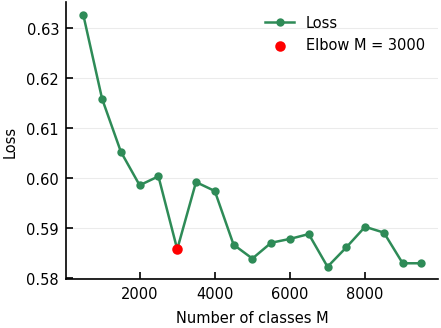

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Nature-style plotting configuration
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150,
    "font.family": "DejaVu Sans", "font.size": 7,
    "axes.labelsize": 7, "axes.titlesize": 7,
    "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "axes.linewidth": 0.8, "lines.linewidth": 1.2, "patch.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3.5, "ytick.major.size": 3.5,
    "xtick.minor.size": 2, "ytick.minor.size": 2,
    "legend.frameon": False,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# ------------------------------------------------------------
# Load dataframe
# ------------------------------------------------------------
df = pd.DataFrame({
    "K": [500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,
          6500,7000,7500,8000,8500,9000,9500],
    "score_norm": [0.632622,0.615861,0.605282,0.598587,0.600370,0.585801,0.599222,
                   0.597440,0.586721,0.583951,0.587111,0.587879,0.588843,
                   0.582315,0.586190,0.590297,0.589137,0.583013,0.583014],
    "is_elbow": [False,False,False,False,False,True,False,False,False,False,
                 False,False,False,False,False,False,False,False,False]
})

# Identify elbow K
K_elbow = df.loc[df["is_elbow"], "K"].iloc[0]

# ------------------------------------------------------------
# Plot (Nature style)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.2, 2.4))

ax.plot(
    df["K"], df["score_norm"], color='#2E8B57',
    marker="o", markersize=3,
    label="Loss"
)

# Highlight elbow point
ax.scatter(
    K_elbow,
    df.loc[df["K"] == K_elbow, "score_norm"],
    color="red", s=18, zorder=5,
    label=f"Elbow M = {int(K_elbow)}"
)

# Axis labels
ax.set_xlabel("Number of classes M")
ax.set_ylabel("Loss")

# ------------------------------------------------------------
# Remove top & right spines
# ------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# Horizontal grid only
# ------------------------------------------------------------
ax.grid(axis="y", alpha=0.25, linewidth=0.5)   # ON for y-axis
ax.grid(visible=False, axis="x")               # OFF for x-axis

ax.legend()

plt.show()


#Stage 2 Tour generation

In [ ]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.cluster import Birch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.special import rel_entr, kl_div
import math
import time

import warnings
warnings.filterwarnings('ignore')

TRIP_MAX_ = 7

# --------------- Memory helpers ---------------

def _downcast_int(s: pd.Series):
    if s.isnull().any():
        return s
    i32 = s.astype(np.int64)
    if i32.min() >= np.iinfo(np.int8).min and i32.max() <= np.iinfo(np.int8).max:
        return i32.astype(np.int8)
    if i32.min() >= np.iinfo(np.int16).min and i32.max() <= np.iinfo(np.int16).max:
        return i32.astype(np.int16)
    if i32.min() >= np.iinfo(np.int32).min and i32.max() <= np.iinfo(np.int32).max:
        return i32.astype(np.int32)
    return i32

def _downcast_float(s: pd.Series):
    return s.astype(np.float32)

def reduce_mem_usage(df: pd.DataFrame, use_cats: bool = True):
    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = _downcast_int(df[col])
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = _downcast_float(df[col])
        elif use_cats and (df[col].nunique(dropna=False) / max(1, len(df[col])) < 0.5):
            df[col] = df[col].astype('category')
    return df

def as_codes(df: pd.DataFrame, cols):
    """Convert columns to categorical codes (int32) consistently, preserving mapping via .cat.categories."""
    for c in cols:
        if not pd.api.types.is_categorical_dtype(df[c]):
            df[c] = df[c].astype('category')
        df[c] = df[c].cat.codes.astype(np.int32)
    return df

# --------------- Math helpers ---------------

def js_div(p, q):
    h = 0.5*np.add(p, q)
    return 0.5*rel_entr(p, h) + 0.5*rel_entr(q, h)

# --------------- Column ops (zero-copy where possible) ---------------

def _renmap(i: int):
    return {
        'TRIP_PURPOSE': f'TRIP_PURPOSE_{i}',
        'TRAVEL_MODE': f'TRAVEL_MODE_{i}',
        'ORIGIN_SUBZONE': f'ORIGIN_SUBZONE_{i}',
        'DESTINATION_SUBZONE': f'DESTINATION_SUBZONE_{i}',
        'TRIP_STARTTIME': f'TRIP_STARTTIME_{i}',
        'TRIP_ENDTIME': f'TRIP_ENDTIME_{i}',
        'ORIGIN_SUBZONE_X': f'ORIGIN_SUBZONE_X_{i}',
        'ORIGIN_SUBZONE_Y': f'ORIGIN_SUBZONE_Y_{i}',
        'DESTINATION_SUBZONE_X': f'DESTINATION_SUBZONE_X_{i}',
        'DESTINATION_SUBZONE_Y': f'DESTINATION_SUBZONE_Y_{i}',
        'Prob_XYZ_fus': f'Prob_{i}',
    }

def rename_columns(df: pd.DataFrame, i: int):
    df.rename(columns=_renmap(i), inplace=True)

# --------------- Sampling utils (no-merge) ---------------

def _prob_sample_indices(prob: np.ndarray, N: int) -> np.ndarray:
    prob = np.asarray(prob, dtype=np.float64)
    prob_sum = prob.sum()
    if prob_sum <= 0:
        # Avoid divide-by-zero; return empty
        return np.array([], dtype=np.int64)
    prob = prob / prob_sum
    # Use cumulative trick to avoid materializing large intermediate df
    return np.random.choice(len(prob), size=N, replace=True, p=prob)

def _select_columns(df: pd.DataFrame, cols):
    # Avoid copying where possible; pandas will create a view if safe.
    return df.loc[:, cols]

# --------------- Core pipeline ---------------

def simulate_trips(df_fus: pd.DataFrame, i: int, N: int) -> pd.DataFrame:
    att_X = ['AGE', 'GENDER', 'TRIP_MAX']
    att_Z = [f'TRIP_PURPOSE_{i}', f'TRAVEL_MODE_{i}',
             f'ORIGIN_SUBZONE_{i}', f'ORIGIN_SUBZONE_X_{i}', f'ORIGIN_SUBZONE_Y_{i}',
             f'DESTINATION_SUBZONE_{i}', f'DESTINATION_SUBZONE_X_{i}', f'DESTINATION_SUBZONE_Y_{i}',
             f'TRIP_STARTTIME_{i}', f'TRIP_ENDTIME_{i}']

    df_sim = df_fus[df_fus['TRIP_CNT'] == i].drop(columns=['TRIP_CNT'])
    rename_columns(df_sim, i)
    df_sim.rename(columns={f'Prob_{i}': 'Prob'}, inplace=True)

    df_sim = _select_columns(df_sim, att_X + att_Z + ['Prob'])
    reduce_mem_usage(df_sim)

    idx = _prob_sample_indices(df_sim['Prob'].to_numpy(), N)
    if len(idx) == 0:
        return df_sim.iloc[0:0][att_X + att_Z]

    # Use iloc/take instead of merging on an artificial index
    out = df_sim.iloc[idx][att_X + att_Z].reset_index(drop=True)
    return reduce_mem_usage(out)

def simulate_tours(df_tours: pd.DataFrame, order: int, N: int) -> pd.DataFrame:
    att_X = ['ID', 'AGE', 'GENDER', 'TRIP_MAX']
    att_Z = []
    for i in range(1, order + 1):
        att_Z.extend([f'TRIP_PURPOSE_{i}', f'TRAVEL_MODE_{i}',
                      f'ORIGIN_SUBZONE_{i}', f'ORIGIN_SUBZONE_X_{i}', f'ORIGIN_SUBZONE_Y_{i}',
                      f'DESTINATION_SUBZONE_{i}', f'DESTINATION_SUBZONE_X_{i}', f'DESTINATION_SUBZONE_Y_{i}',
                      f'TRIP_STARTTIME_{i}', f'TRIP_ENDTIME_{i}'])

    # Prob normalization without extra copy
    probs = df_tours['Prob'].to_numpy(dtype=np.float64)
    probs = probs / probs.sum() if probs.sum() > 0 else probs
    idx = _prob_sample_indices(probs, N)
    if len(idx) == 0:
        return df_tours.iloc[0:0][att_X + att_Z]

    out = df_tours.iloc[idx][att_X + att_Z].reset_index(drop=True)
    return reduce_mem_usage(out)

def next_start_times(df_hts_: pd.DataFrame) -> pd.DataFrame:
    # Build minimal table, count combos, then convert to conditional P(start_next | end_prev, purpose_prev)
    t = df_hts_[['ACTIVITY_STARTTIME', 'TRIP_PURPOSE', 'ACTIVITY_DURATION']].copy()
    t['TRIP_STARTTIME'] = t['ACTIVITY_STARTTIME'] + t['ACTIVITY_DURATION']
    t = t.rename(columns={'ACTIVITY_STARTTIME': 'TRIP_ENDTIME'}).drop(columns=['ACTIVITY_DURATION'])

    # Use value_counts -> Prob -> conditional
    t['Numbers'] = 1.0
    grp_keys = ['TRIP_ENDTIME', 'TRIP_PURPOSE', 'TRIP_STARTTIME']
    agg = t.groupby(grp_keys, observed=True)['Numbers'].sum().astype(np.float64).reset_index()
    agg['Prob'] = agg['Numbers'] / agg['Numbers'].sum()
    agg.drop(columns=['Numbers'], inplace=True)

    base_keys = ['TRIP_ENDTIME', 'TRIP_PURPOSE']
    agg['Prob_base'] = agg.groupby(base_keys, observed=True)['Prob'].transform('sum')
    agg['Prob_cond'] = (agg['Prob'] / agg['Prob_base']).astype(np.float32)
    agg = agg.drop(columns=['Prob_base', 'Prob'])

    # Downcast & codes for join keys
    reduce_mem_usage(agg)
    return agg.dropna()

def _prep_ith_trips(df_fus: pd.DataFrame, i: int) -> pd.DataFrame:
    # Slice, rename, then build conditional Prob over (X, Y, O, S)
    cols_keep = ['AGE', 'GENDER', 'TRIP_MAX', 'TRIP_CNT',
                 'TRIP_PURPOSE', 'TRAVEL_MODE',
                 'ORIGIN_SUBZONE', 'ORIGIN_SUBZONE_X', 'ORIGIN_SUBZONE_Y',
                 'DESTINATION_SUBZONE', 'DESTINATION_SUBZONE_X', 'DESTINATION_SUBZONE_Y',
                 'TRIP_STARTTIME', 'TRIP_ENDTIME', 'Prob_XYZ_fus']
    ith = df_fus.loc[df_fus['TRIP_CNT'] == i, cols_keep].copy()
    ith.drop(columns=['TRIP_CNT'], inplace=True)
    rename_columns(ith, i)

    # Group denominator: sum Prob over X,Y,O,S
    den_keys = ['AGE', 'GENDER', 'TRIP_MAX', f'ORIGIN_SUBZONE_{i}', f'TRIP_STARTTIME_{i}']
    ith['Prob_den'] = ith.groupby(den_keys, observed=True)[f'Prob_{i}'].transform('sum')
    ith[f'Prob_{i}'] = (ith[f'Prob_{i}'] / ith['Prob_den']).astype(np.float32)
    ith.drop(columns=['Prob_den'], inplace=True)

    return reduce_mem_usage(ith)

def concat_trips(df_tours: pd.DataFrame,
                 df_ith_trips: pd.DataFrame,
                 df_next_start_times: pd.DataFrame,
                 i: int):
    # Build minimal PRE_* keys to join
    tours = df_tours.copy()
    tours['PRE_SUBZONE'] = tours[f'DESTINATION_SUBZONE_{i-1}']
    tours['PRE_PURPOSE'] = tours[f'TRIP_PURPOSE_{i-1}']
    tours['PRE_ENDTIME'] = tours[f'TRIP_ENDTIME_{i-1}']

    nst = df_next_start_times.rename(columns={
        'TRIP_PURPOSE': 'PRE_PURPOSE',
        'TRIP_ENDTIME': 'PRE_ENDTIME',
        'TRIP_STARTTIME': 'PRE_STARTTIME'
    }, errors='ignore')

    ith = df_ith_trips.copy()
    ith['PRE_SUBZONE'] = ith[f'ORIGIN_SUBZONE_{i}']
    ith['PRE_STARTTIME'] = ith[f'TRIP_STARTTIME_{i}']

    # Left-join tours with cond P(next start | prev end, purpose) to get Prob_cond
    tours = tours.merge(
        nst[[#'AGE', 'GENDER', 'TRIP_MAX',
            'PRE_PURPOSE', 'PRE_ENDTIME', 'PRE_STARTTIME', 'Prob_cond']],
        on=[#'AGE', 'GENDER', 'TRIP_MAX',
            'PRE_PURPOSE', 'PRE_ENDTIME'],
        how='left',
        copy=False
    )

    # Keyed join with i-th trips on (X, Y, PRE_SUBZONE, PRE_STARTTIME)
    join_keys = ['AGE', 'GENDER', 'TRIP_MAX', 'PRE_SUBZONE', 'PRE_STARTTIME']
    tours = tours.merge(
        ith[join_keys + [f'TRIP_PURPOSE_{i}', f'TRAVEL_MODE_{i}',
                         f'ORIGIN_SUBZONE_{i}', f'ORIGIN_SUBZONE_X_{i}', f'ORIGIN_SUBZONE_Y_{i}',
                         f'DESTINATION_SUBZONE_{i}', f'DESTINATION_SUBZONE_X_{i}', f'DESTINATION_SUBZONE_Y_{i}',
                         f'TRIP_STARTTIME_{i}', f'TRIP_ENDTIME_{i}', f'Prob_{i}']],
        on=join_keys,
        how='inner',
        copy=False
    )

    # Combine probabilities
    tours['Prob'] = (tours[f'Prob_{i}'] * tours['Prob_cond']).astype(np.float32)
    tours.drop(columns=[f'Prob_{i}', 'Prob_cond', 'PRE_SUBZONE', 'PRE_PURPOSE', 'PRE_ENDTIME', 'PRE_STARTTIME'], inplace=True)

    # Split complete vs incomplete
    mask_done = (tours['TRIP_MAX'] == i)
    mask_home = mask_done & (tours[f'TRIP_PURPOSE_{i}'] == 0)

    complete_home = tours.loc[mask_home].copy()
    # Enforce return to home
    complete_home[f'DESTINATION_SUBZONE_{i}']   = complete_home['ORIGIN_SUBZONE_1']
    complete_home[f'DESTINATION_SUBZONE_X_{i}'] = complete_home['ORIGIN_SUBZONE_X_1']
    complete_home[f'DESTINATION_SUBZONE_Y_{i}'] = complete_home['ORIGIN_SUBZONE_Y_1']

    complete_nohome = tours.loc[mask_done & ~mask_home]
    df_tours_complete = pd.concat([complete_home, complete_nohome], ignore_index=True)

    df_tours_incomplete = tours.loc[~mask_done]

    return reduce_mem_usage(df_tours_complete), reduce_mem_usage(df_tours_incomplete)


def generate_tours(df_fus, df_next_start_times, N):
    """
    Generate tours by iterating over demographic cohorts (gender, age, trip_max),
    then progressively extending trips step-by-step using conditional probabilities.
    Logic unchanged; only variable names, comments, and progress prints are improved.
    """
    import math

    # Scaling factors for seeding and per-step simulation
    seed_scale = 3         # same as "scale" in original
    per_step_scale = 4     # same as "scale_" in original

    # -------------------------------------------------------------
    # (1) Seed initial tours (TRIP_CNT == 1)
    # -------------------------------------------------------------
    df_seed_candidates = df_fus[df_fus['TRIP_CNT'] == 1]
    df_tours_seeded = simulate_trips(df_seed_candidates, 1, int(seed_scale * N))
    df_tours_seeded = df_tours_seeded.sort_values(by=['TRIP_MAX'], ascending=False).reset_index()
    df_tours_seeded['ID'] = df_tours_seeded['index']
    df_tours_seeded = df_tours_seeded.drop(columns=['index'])

    print(f"[INIT] Seeded {len(df_tours_seeded):,} initial tours from TRIP_CNT=1")

    # -------------------------------------------------------------
    # (2) Iterate over all cohorts
    # -------------------------------------------------------------
    df_all_results = pd.DataFrame()  # aggregated result

    for gender in range(0, 2):
        for age in range(0, 8):
            for tmax in reversed(range(2, TRIP_MAX_ + 1)):
                print(f"\n[COHORT] Gender={gender}, Age={age}, TripMax={tmax}")

                # Filter for this (gender, age, tripmax)
                df_fus_cohort = df_fus[
                    (df_fus['GENDER'] == gender) &
                    (df_fus['AGE'] == age) &
                    (df_fus['TRIP_MAX'] == tmax)
                ]
                df_tours_cohort = df_tours_seeded[
                    (df_tours_seeded['GENDER'] == gender) &
                    (df_tours_seeded['AGE'] == age) &
                    (df_tours_seeded['TRIP_MAX'] == tmax)
                ]

                # Skip empty cohorts
                if len(df_tours_cohort) == 0:
                    print("  → No tours in this cohort, skipping.")
                    continue

                # Chunking for memory control
                chunk_size = 50000 #20000
                cohort_chunks = [
                    df_tours_cohort[i:i + chunk_size]
                    for i in range(0, df_tours_cohort.shape[0], chunk_size)
                ]
                num_chunks = math.ceil(len(df_tours_cohort) / chunk_size)
                print(f"  → Number of chunks: {num_chunks} (chunk size = {chunk_size})")

                # -------------------------------------------------------------
                # (3) Process each chunk
                # -------------------------------------------------------------
                for chunk_idx in range(num_chunks):
                    df_tours_chunk = cohort_chunks[chunk_idx]
                    df_results_chunk = pd.DataFrame()

                    print(f"    [Chunk {chunk_idx + 1}/{num_chunks}] "
                        f"Processing {len(df_tours_chunk):,} tours...")

                    # Step through each trip number (2 → TRIP_MAX_)
                    for trip_idx in range(2, TRIP_MAX_ + 1):
                        df_trips_i = df_fus_cohort[df_fus_cohort['TRIP_CNT'] == trip_idx].drop(columns=['TRIP_CNT'])
                        rename_columns(df_trips_i, trip_idx)

                        # Compute conditional probabilities
                        df_trips_i['Prob_'] = df_trips_i.groupby(
                            ['AGE', 'GENDER', 'TRIP_MAX',
                            f'ORIGIN_SUBZONE_{trip_idx}', f'TRIP_STARTTIME_{trip_idx}']
                        )[f'Prob_{trip_idx}'].transform('sum')
                        df_trips_i[f'Prob_{trip_idx}'] = df_trips_i[f'Prob_{trip_idx}'] / df_trips_i['Prob_']
                        df_trips_i = df_trips_i.drop(columns=['Prob_'])

                        # Join partial tours and extend
                        df_complete, df_incomplete = concat_trips(
                            df_tours_chunk, df_trips_i, df_next_start_times, trip_idx
                        )
                        step_sample_size = per_step_scale * chunk_size

                        # Handle completed tours
                        if len(df_complete) > 0:
                            df_results_chunk = pd.concat(
                                [df_results_chunk, simulate_tours(df_complete, trip_idx, int(step_sample_size))]
                            )

                        # Continue with incomplete tours if available
                        if len(df_incomplete) > 0:
                            df_tours_chunk = simulate_tours(df_incomplete, trip_idx, int(step_sample_size))
                        else:
                            break

                    # Keep only first completion per ID
                    df_results_chunk = df_results_chunk.drop_duplicates(subset=['ID'], keep='first')
                    df_all_results = pd.concat([df_all_results, df_results_chunk])

                    print(f"    → Finished chunk {chunk_idx + 1}/{num_chunks}, "
                        f"Accumulated tours: {len(df_all_results):,}")

    print(f"\n[COMPLETE] Total generated tours: {len(df_all_results):,}")
    return df_all_results, df_tours_seeded


def generate_tours_scaled(df_result_all, df_tours_seeded, N):
    """
    Downsample simulated tours to match TRIP_MAX distribution observed in the seeded tours.
    Logic unchanged; clearer variable names, structured comments, and informative progress prints.
    """
    # -------------------------------------------------------------
    # (1) Compute TRIP_MAX proportions from seeded tours
    # -------------------------------------------------------------
    df_tripmax_dist = df_tours_seeded[['AGE', 'GENDER', 'TRIP_MAX']].copy()
    df_tripmax_dist['Count'] = 1.0

    # Aggregate counts per (AGE, GENDER, TRIP_MAX)
    df_tripmax_dist['Count'] = df_tripmax_dist.groupby(
        ['AGE', 'GENDER', 'TRIP_MAX']
    )['Count'].transform('sum')

    df_tripmax_dist = df_tripmax_dist.drop_duplicates()
    df_tripmax_dist['Pop'] = df_tripmax_dist['Count'] / df_tripmax_dist['Count'].sum()
    df_tripmax_dist = df_tripmax_dist.drop(columns=['Count']).sort_values(
        ['AGE', 'GENDER', 'TRIP_MAX'], ascending=True
    ).reset_index(drop=True)

    tripmax_to_pop = df_tripmax_dist.set_index(['AGE', 'GENDER', 'TRIP_MAX'])['Pop'].to_dict()

    print(f"[INIT] Derived TRIP_MAX proportions from seeded tours:")
    for (age, gender, tmax), pop in tripmax_to_pop.items():
        print(f"   Age={age}, Gender={gender}, TripMax={tmax}: {pop:.4f}")

    # -------------------------------------------------------------
    # (2) Downsample simulated results per cohort
    # -------------------------------------------------------------
    df_result_final = pd.DataFrame()
    total_before = len(df_result_all)

    print("\n[SCALING] Adjusting simulated tours to match TRIP_MAX proportions...")

    for (age, gender, tmax), pop in tripmax_to_pop.items():
        df_subset = df_result_all[
            (df_result_all['TRIP_MAX'] == tmax) &
            (df_result_all['AGE'] == age) &
            (df_result_all['GENDER'] == gender)
        ]
        current_count = len(df_subset)
        target_count = N * pop  # keep N global as in original

        if current_count == 0:
            print(f"  → Cohort (A={age}, G={gender},  Tmax={tmax}) has 0 tours, skipped.")
            continue

        if current_count > target_count:
            sample_frac = target_count / current_count
            df_subset = df_subset.sample(frac=sample_frac)
            print(f"  → Downsampled (A={age}, G={gender}, Tmax={tmax}) "
                  f"from {current_count:,} → {len(df_subset):,} ({sample_frac:.3f})")
        else:
            print(f"  → Kept all {current_count:,} tours for (A={age}, G={gender}, Tmax={tmax})")

        df_result_final = pd.concat([df_result_final, df_subset])

    print(f"\n[COMPLETE] Final sample size: {len(df_result_final):,} "
          f"(from original {total_before:,})")
    return df_result_final


# ------------------------------------------------------------
# __main__: Example end-to-end run (adjust paths)
# ------------------------------------------------------------
reg = 'sgp'
start_time = time.time()
df_hts = pd.read_csv(path_data + f'data_{reg}_hts_trip.csv')
df_fus = pd.read_csv(path_result + f'case_{reg}_sim_trip_M_3000.csv')
df_fus = reduce_mem_usage(df_fus)
print('df_fus lenght', len(df_fus))

df_next_start_times = next_start_times(df_hts)

NN = 5.5e6

df_fus, df_tours = generate_tours(df_fus, df_next_start_times, NN)
df_fus = generate_tours_scaled(df_fus, df_tours, NN)
print(df_fus.info())
df_fus.to_csv(path_result + f'case_{reg}_sim_tour_M_3000.csv', index = False) # or z1 is correct? z2 is with income

print('Time take %s seconds' % (time.time() - start_time))
print('Done!')

df_fus lenght 69917684
[INIT] Seeded 16,500,000 initial tours from TRIP_CNT=1

[COHORT] Gender=0, Age=0, TripMax=7
  → No tours in this cohort, skipping.

[COHORT] Gender=0, Age=0, TripMax=6
  → No tours in this cohort, skipping.

[COHORT] Gender=0, Age=0, TripMax=5
  → Number of chunks: 1 (chunk size = 50000)
    [Chunk 1/1] Processing 1,146 tours...
    → Finished chunk 1/1, Accumulated tours: 1,095

[COHORT] Gender=0, Age=0, TripMax=4
  → Number of chunks: 1 (chunk size = 50000)
    [Chunk 1/1] Processing 644 tours...
    → Finished chunk 1/1, Accumulated tours: 1,730

[COHORT] Gender=0, Age=0, TripMax=3
  → Number of chunks: 1 (chunk size = 50000)
    [Chunk 1/1] Processing 13,499 tours...
    → Finished chunk 1/1, Accumulated tours: 15,174

[COHORT] Gender=0, Age=0, TripMax=2
  → Number of chunks: 2 (chunk size = 50000)
    [Chunk 1/2] Processing 50,000 tours...
    → Finished chunk 1/2, Accumulated tours: 62,348
    [Chunk 2/2] Processing 32,095 tours...
    → Finished chunk 2/2,

# Stage 2 Add income

In [ ]:
import numpy as np
import pandas as pd

def _build_income_distributions(df_hts, income_col="INCOME"):
    """
    Build empirical income distributions for different conditioning levels.

    Returns: list of dicts, each with:
        - "cols": tuple of columns used as key
        - "dists": dict mapping key tuple -> {"values": [...], "probs": [...]}
    """
    groupings = [
        ("AGE", "GENDER", "TRIP_MAX", "ORIGIN_SUBZONE_1"),
        ("AGE", "GENDER", "TRIP_MAX"),
        ("AGE", "GENDER"),
    ]

    dists_by_level = []

    for cols in groupings:
        # Compute normalized counts: P(INCOME | cols)
        vc = (
            df_hts
            .groupby(list(cols))[income_col]
            .value_counts(normalize=True)
        )  # MultiIndex: (*cols, income_value) -> prob

        level_dict = {}

        for idx, prob in vc.items():
            key = idx[:len(cols)]          # tuple of the conditioning variables
            income_val = idx[len(cols)]    # the INCOME category

            if key not in level_dict:
                level_dict[key] = {"values": [], "probs": []}
            level_dict[key]["values"].append(income_val)
            level_dict[key]["probs"].append(prob)

        dists_by_level.append({"cols": cols, "dists": level_dict})

    # Global (unconditional) income distribution as final fallback
    global_vc = df_hts[income_col].value_counts(normalize=True)
    global_dist = {
        "values": global_vc.index.to_list(),
        "probs": global_vc.values.tolist()
    }

    return dists_by_level, global_dist


def _simulate_income_for_row(row, dists_by_level, global_dist):
    """
    Simulate an INCOME value for a single row using backoff hierarchy.
    """
    # Try each conditioning level in order
    for level in dists_by_level:
        cols = level["cols"]
        key = tuple(row[c] for c in cols)
        d = level["dists"].get(key)

        if d is not None:
            return np.random.choice(d["values"], p=d["probs"])

    # If nothing found, use global distribution
    return np.random.choice(global_dist["values"], p=global_dist["probs"])


def add_simulated_income(df_fus, df_hts, income_col="INCOME", new_col_name="INCOME"):
    """
    Add simulated INCOME to df_fus based on df_hts using hierarchical matching.

    Parameters
    ----------
    df_fus : pd.DataFrame
        Has columns [AGE, GENDER, TRIP_MAX, ORIGIN_SUBZONE_1].
    df_hts : pd.DataFrame
        Has columns [AGE, GENDER, TRIP_MAX, INCOME, ORIGIN_SUBZONE_1].
    income_col : str
        Name of the income column in df_hts.
    new_col_name : str
        Name of the column to write into df_fus (default: "INCOME").

    Returns
    -------
    df_fus_with_income : pd.DataFrame
        Copy of df_fus with simulated income column added.
    """
    # Build conditional income distributions from HTS
    dists_by_level, global_dist = _build_income_distributions(df_hts, income_col=income_col)

    # Work on a copy to avoid modifying original df_fus in-place
    df_out = df_fus.copy()

    # Vectorized-like apply over rows (row-wise because each row may use different key)
    df_out[new_col_name] = df_out.apply(
        lambda r: _simulate_income_for_row(r, dists_by_level, global_dist),
        axis=1
    )

    return df_out


################################

reg = 'sgp'

df_fus = pd.read_csv(path_result + f'case_{reg}_sim_tour_M_3000.csv')
df_hts = pd.read_csv(path_data + f'data_{reg}_hts_tour.csv')

df_fus_with_income = add_simulated_income(df_fus, df_hts, income_col="INCOME", new_col_name="INCOME")

df_fus_with_income.to_csv(path_result + f'case_{reg}_sim_tour_M_3000_income.csv', index = False)
print(df_fus_with_income)

               ID  AGE  GENDER  TRIP_MAX  TRIP_PURPOSE_1  TRAVEL_MODE_1  \
0          715939    0       0         2               3              1   
1         5111892    0       0         2               4              1   
2         7006304    0       0         2               4              0   
3         4767002    0       0         2               5              1   
4        13247722    0       0         2               5              1   
...           ...  ...     ...       ...             ...            ...   
5499001   7822997    7       1         5               5              1   
5499002   3345467    7       1         5               5              1   
5499003     16738    7       1         5               5              1   
5499004   4486617    7       1         5               0              0   
5499005  11732829    7       1         5               0              0   

        ORIGIN_SUBZONE_1  ORIGIN_SUBZONE_X_1  ORIGIN_SUBZONE_Y_1  \
0                 HGSZ04       

# =================================================